# YouTube 热门视频爆款影响因素分析与识别模型构建

## 1. 项目背景与研究目标

### 1.1项目背景
随着短视频和在线视频平台的快速发展，内容已经成为平台获取流量、提升用户活跃度和增强用户粘性的核心驱动力。对于YouTube等内容平台而言，热门视频不仅能够为平台带来大量流量和广告收益，还能够提升创作者活跃度，促进内容生态的持续增长。

然而，在海量内容不断涌入的背景下，并非所有视频都能够获得广泛传播。部分视频能够迅速获得大量曝光并进入热门榜单，而更多视频则难以获得持续关注。因此，识别影响视频热度的关键因素，研究爆款视频的形成机制，对于优化内容推荐策略、提升内容运营效率以及帮助创作者制定内容生产策略具有重要意义。

本项目基于YouTube Trending Dataset，对美国地区热门视频数据进行分析，从内容分类、发布时间、创作者影响力以及内容包装方式等多个维度探究视频热度的影响因素，并进一步构建爆款视频预测模型，为内容平台运营决策提供数据支持。

### 1.2 业务问题定义
对于内容平台而言，提升优质内容的发现效率和爆款内容产出率是内容运营的重要目标。

围绕这一业务场景，本项目重点关注以下问题：

- 哪些内容分类更容易产生爆款视频？
- 发布时间是否会影响视频传播效果？
- 创作者影响力与视频热度之间存在怎样的关联？
- 内容标题和标签等包装因素是否会影响传播效果？
- 能否通过机器学习模型识别 Trending 样本中达到爆款标准的视频？

### 1.3 研究目标
本项目旨在通过对YouTube热门视频数据的系统分析，识别影响视频热度的关键因素，并建立爆款视频预测模型。

具体目标包括：

1. 构建内容传播分析指标体系
2. 分析不同内容赛道的竞争格局与爆款率差异
3. 利用机器学习模型预测视频成为爆款的可能性
4. 基于分析结果提出内容运营与推荐策略建议

### 1.4分析框架
具体分析流程如下：

数据获取

↓

数据清洗与预处理

↓

SQL指标构建

↓

内容生态分析

↓

爆款视频形成机制分析

↓

爆款视频预测模型构建

↓

运营策略建议输出

## 2. 数据理解与字段说明
### 2.1 数据来源

本项目使用 Kaggle 平台公开数据集 **YouTube Trending Video Dataset**，选取其中美国地区热门视频数据作为研究对象。

本项目主要使用两个文件：

| 文件名 | 文件类型 | 作用 |
|---|---|---|
| USvideos.csv | CSV | 美国地区 YouTube 热门视频数据 |
| US_category_id.json | JSON | 视频分类编号映射文件 |

其中，`USvideos.csv` 是核心分析数据，包含视频标题、频道、发布时间、分类、播放量、点赞数、评论数等字段；`US_category_id.json` 用于将 `category_id` 映射为具体内容分类名称，例如 Music、Gaming、Entertainment、Sports 等。

---

### 2.2 数据规模与结构

本节首先读取原始数据，并查看数据规模、字段结构和数据类型，为后续数据清洗和指标构建做准备。

In [69]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据
videos = pd.read_csv("USvideos.csv")

with open("US_category_id.json", "r", encoding="utf-8") as f:
    category_json = json.load(f)

# 查看数据规模
videos.shape

(40949, 16)

In [70]:
# 查看前5行数据
videos.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,2kyS6SvSYSE,17.14.11,WE WANT TO TALK ABOUT OUR MARRIAGE,CaseyNeistat,22,2017-11-13T17:13:01.000Z,SHANtell martin,748374,57527,2966,15954,https://i.ytimg.com/vi/2kyS6SvSYSE/default.jpg,False,False,False,SHANTELL'S CHANNEL - https://www.youtube.com/s...
1,1ZAPwfrtAFY,17.14.11,The Trump Presidency: Last Week Tonight with J...,LastWeekTonight,24,2017-11-13T07:30:00.000Z,"last week tonight trump presidency|""last week ...",2418783,97185,6146,12703,https://i.ytimg.com/vi/1ZAPwfrtAFY/default.jpg,False,False,False,"One year after the presidential election, John..."
2,5qpjK5DgCt4,17.14.11,"Racist Superman | Rudy Mancuso, King Bach & Le...",Rudy Mancuso,23,2017-11-12T19:05:24.000Z,"racist superman|""rudy""|""mancuso""|""king""|""bach""...",3191434,146033,5339,8181,https://i.ytimg.com/vi/5qpjK5DgCt4/default.jpg,False,False,False,WATCH MY PREVIOUS VIDEO ▶ \n\nSUBSCRIBE ► http...
3,puqaWrEC7tY,17.14.11,Nickelback Lyrics: Real or Fake?,Good Mythical Morning,24,2017-11-13T11:00:04.000Z,"rhett and link|""gmm""|""good mythical morning""|""...",343168,10172,666,2146,https://i.ytimg.com/vi/puqaWrEC7tY/default.jpg,False,False,False,Today we find out if Link is a Nickelback amat...
4,d380meD0W0M,17.14.11,I Dare You: GOING BALD!?,nigahiga,24,2017-11-12T18:01:41.000Z,"ryan|""higa""|""higatv""|""nigahiga""|""i dare you""|""...",2095731,132235,1989,17518,https://i.ytimg.com/vi/d380meD0W0M/default.jpg,False,False,False,I know it's been a while since we did this sho...


In [71]:
# 查看字段信息和数据类型
videos.info()

<class 'pandas.DataFrame'>
RangeIndex: 40949 entries, 0 to 40948
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   video_id                40949 non-null  str  
 1   trending_date           40949 non-null  str  
 2   title                   40949 non-null  str  
 3   channel_title           40949 non-null  str  
 4   category_id             40949 non-null  int64
 5   publish_time            40949 non-null  str  
 6   tags                    40949 non-null  str  
 7   views                   40949 non-null  int64
 8   likes                   40949 non-null  int64
 9   dislikes                40949 non-null  int64
 10  comment_count           40949 non-null  int64
 11  thumbnail_link          40949 non-null  str  
 12  comments_disabled       40949 non-null  bool 
 13  ratings_disabled        40949 non-null  bool 
 14  video_error_or_removed  40949 non-null  bool 
 15  description             40379 

### 2.3 字段说明

根据字段的业务含义，可以将原始数据字段划分为五类：

| 字段类型 | 字段 |
|---|---|
| 视频基础信息 | video_id、title、channel_title |
| 内容属性信息 | category_id、tags、description |
| 时间信息 | publish_time、trending_date |
| 热度表现信息 | views、likes、dislikes、comment_count |
| 状态信息 | comments_disabled、ratings_disabled、video_error_or_removed |

各字段含义如下：

| 字段 | 含义 |
|---|---|
| video_id | 视频唯一标识 |
| trending_date | 视频进入热门榜日期 |
| title | 视频标题 |
| channel_title | 创作者频道名称 |
| category_id | 视频分类编号 |
| publish_time | 视频发布时间 |
| tags | 视频标签 |
| views | 播放量 |
| likes | 点赞数 |
| dislikes | 点踩数 |
| comment_count | 评论数 |
| thumbnail_link | 缩略图链接 |
| comments_disabled | 是否关闭评论 |
| ratings_disabled | 是否关闭评分 |
| video_error_or_removed | 视频是否失效或被删除 |
| description | 视频描述 |

### 2.4 分类映射文件理解

`US_category_id.json` 文件用于将 `category_id` 转换为可读的内容分类名称。  
例如：

- 10 → Music
- 17 → Sports
- 20 → Gaming
- 24 → Entertainment
- 25 → News & Politics

后续分析中会将分类编号映射为分类名称，便于进行内容赛道分析。

In [72]:
# 提取 category_id 与 category_name 映射关系
category_mapping = []

for item in category_json["items"]:
    category_mapping.append({
        "category_id": int(item["id"]),
        "category_name": item["snippet"]["title"]
    })

category_df = pd.DataFrame(category_mapping)

category_df.head()

,category_id,category_name
0,1,Film & Animation
1,2,Autos & Vehicles
2,10,Music
3,15,Pets & Animals
4,17,Sports


### 2.5 数据质量初步检查

在正式清洗前，需要先检查数据是否存在缺失值、重复值和异常字段类型。

In [73]:
# 缺失值统计
missing_values = videos.isnull().sum().sort_values(ascending=False)
missing_values

description               570
video_id                    0
title                       0
trending_date               0
category_id                 0
publish_time                0
tags                        0
channel_title               0
views                       0
likes                       0
comment_count               0
dislikes                    0
thumbnail_link              0
comments_disabled           0
ratings_disabled            0
video_error_or_removed      0
dtype: int64

In [74]:
# 重复行数量
print("重复行数量:", videos.duplicated().sum())

重复行数量: 48


In [75]:
# 数值型字段描述统计
print("数值型字段描述统计:")
videos[["views", "likes", "dislikes", "comment_count"]].describe()

数值型字段描述统计:


,views,likes,dislikes,comment_count
count,4.094900e+04,4.094900e+04,4.094900e+04,4.094900e+04
mean,2.360785e+06,7.426670e+04,3.711401e+03,8.446804e+03
std,7.394114e+06,2.288853e+05,2.902971e+04,3.743049e+04
min,5.490000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.423290e+05,5.424000e+03,2.020000e+02,6.140000e+02
50%,6.818610e+05,1.809100e+04,6.310000e+02,1.856000e+03
75%,1.823157e+06,5.541700e+04,1.938000e+03,5.755000e+03
max,2.252119e+08,5.613827e+06,1.674420e+06,1.361580e+06


### 2.6 本章小结

本章完成了对 YouTube 美国热门视频数据的初步理解。数据集中包含视频基础信息、内容属性、发布时间、用户互动表现和视频状态等字段，能够支持后续从内容分类、发布时间、互动行为、创作者影响力以及内容包装等角度分析爆款视频形成机制。

下一章将对原始数据进行清洗与预处理，包括缺失值处理、重复值处理、时间字段转换、分类映射以及异常值检查。

## 3. 数据清洗与预处理

### 3.1 缺失值处理

为保证后续分析结果的准确性，首先对数据集中的缺失值进行检查。

由于缺失值可能导致统计结果偏差或影响模型训练，因此需要根据字段业务含义制定相应处理策略。

In [76]:
# 缺失值统计
missing_df = pd.DataFrame({
    "Missing_Count": videos.isnull().sum(),
    "Missing_Rate(%)": round(videos.isnull().mean()*100,2)
})

missing_df.sort_values(
    by="Missing_Count",
    ascending=False
)

,Missing_Count,Missing_Rate(%)
description,570,1.39
video_id,0,0.00
title,0,0.00
trending_date,0,0.00
category_id,0,0.00
publish_time,0,0.00
tags,0,0.00
channel_title,0,0.00
views,0,0.00
likes,0,0.00


经检查发现，仅 description 字段存在少量缺失，其余核心分析字段不存在缺失情况。

由于视频描述不参与核心传播指标计算，因此采用空字符串进行填充处理。

In [77]:
# 处理缺失值：description 字段缺失较多，可以选择填充空字符串
videos["description"] = videos["description"].fillna("")

### 3.2 重复值处理
在初步筛查中,重复行数为48，重复记录可能导致统计结果失真，因此需要删除重复数据，仅保留唯一记录。

In [78]:

videos = videos.drop_duplicates()
print("重复行数量:", videos.duplicated().sum())

重复行数量: 0


### 3.3 时间字段处理
原始数据中的发布时间字段为字符串格式，不利于时间维度分析，因此需要转换为标准时间格式，并进一步提取时间特征。

In [79]:
videos["publish_time"] = pd.to_datetime(
    videos["publish_time"]
)

为了分析发布时间对视频热度的影响，从原始时间字段中提取年份、月份、星期以及小时等时间特征。

In [80]:

videos["publish_year"] = videos["publish_time"].dt.year
videos["publish_month"] = videos["publish_time"].dt.month
videos["publish_weekday"] = videos["publish_time"].dt.day_name()
videos["publish_hour"] = videos["publish_time"].dt.hour

videos[
    [
        "publish_time",
        "publish_year",
        "publish_month",
        "publish_weekday",
        "publish_hour"
    ]
].head()

,publish_time,publish_year,publish_month,publish_weekday,publish_hour
0,2017-11-13 17:13:01+00:00,2017,11,Monday,17
1,2017-11-13 07:30:00+00:00,2017,11,Monday,7
2,2017-11-12 19:05:24+00:00,2017,11,Sunday,19
3,2017-11-13 11:00:04+00:00,2017,11,Monday,11
4,2017-11-12 18:01:41+00:00,2017,11,Sunday,18


### 3.4 分类字段映射
原始数据中的 category_id 为数字编码，不利于结果展示和业务分析，因此需要结合分类映射文件将其转换为具体内容分类名称。

In [81]:
category_df.head()

,category_id,category_name
0,1,Film & Animation
1,2,Autos & Vehicles
2,10,Music
3,15,Pets & Animals
4,17,Sports


In [82]:
#将分类映射表与视频数据进行关联，生成 category_name 字段
videos = videos.merge(
    category_df,
    on="category_id",
    how="left"
)
#
videos[
    [
        "category_id",
        "category_name"
    ]
].head()

,category_id,category_name
0,22,People & Blogs
1,24,Entertainment
2,23,Comedy
3,24,Entertainment
4,24,Entertainment


### 3.5 数据粒度识别与视频去重

通过数据理解发现，当前数据集记录的是视频进入 Trending 榜单的历史记录，因此同一个视频可能在不同日期重复出现。为了避免重复上榜记录对后续分析造成影响，本项目以 video_id 为唯一标识，对数据进行去重处理，并保留每个视频最后一次上榜记录作为其最终表现。
需要特别说明的是，原始数据中的 trending_date 采用 yy.dd.mm（年-日-月）格式，直接对字符串排序会导致时序错乱，因此需先解析为真实日期再进行排序。

处理后，数据粒度由“上榜记录”统一为“视频粒度”，后续分析均基于去重后的数据开展。

In [83]:
# 将 trending_date 解析为真实日期（原始格式为 yy.dd.mm，需指定 format）
videos["trending_date_dt"] = pd.to_datetime(
    videos["trending_date"],
    format="%y.%d.%m"
)

videos = (
    videos
    .sort_values("trending_date_dt")
    .drop_duplicates(
        subset="video_id",
        keep="last"
    )
    .drop(columns=["trending_date_dt"])
)
videos.shape


(6351, 21)

### 3.6 异常值检查
播放量、点赞数和评论数等指标通常具有明显长尾特征，因此需要对其分布情况进行检查。

In [84]:
videos[
    [
        "views",
        "likes",
        "dislikes",
        "comment_count"
    ]
].describe()

,views,likes,dislikes,comment_count
count,6.351000e+03,6.351000e+03,6.351000e+03,6.351000e+03
mean,1.962117e+06,5.557505e+04,3.067153e+03,6.450745e+03
std,7.060057e+06,1.938307e+05,3.198849e+04,3.382370e+04
min,5.590000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.591565e+05,2.772500e+03,1.270000e+02,3.720000e+02
50%,5.181070e+05,1.190600e+04,4.440000e+02,1.266000e+03
75%,1.473582e+06,3.842850e+04,1.507000e+03,4.061500e+03
max,2.252119e+08,5.613827e+06,1.674420e+06,1.361580e+06


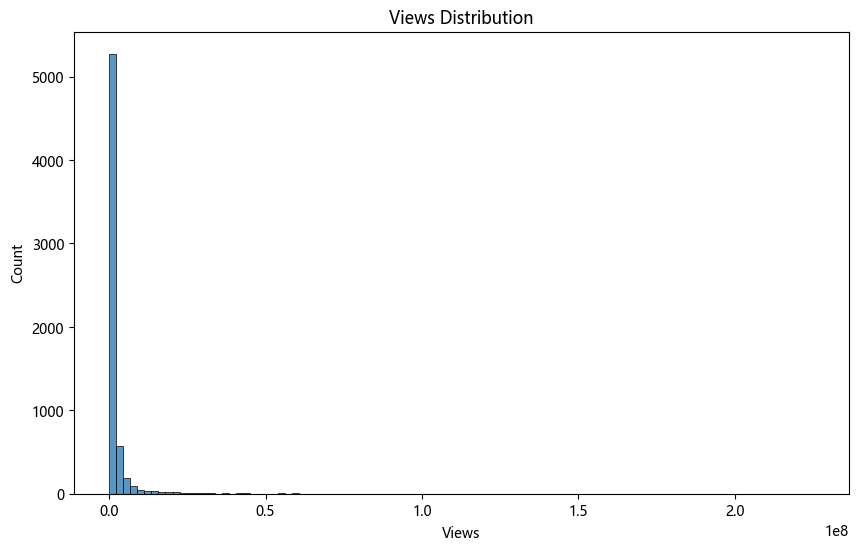

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))

sns.histplot(
    videos["views"],
    bins=100
)

plt.title("Views Distribution")
plt.xlabel("Views")
plt.ylabel("Count")

plt.show()

从播放量分布图可以看出，大部分视频集中在较低播放量区间，而少数视频拥有极高播放量。由于极高播放量视频的存在，横轴被明显拉长，导致大量样本集中分布在左侧区域，呈现典型的右偏长尾分布特征。考虑到本项目研究对象本身为热门视频，因此这些高热度样本属于真实业务现象，不进行异常值删除处理。


### 3.6 数据预处理结果


In [86]:
#将清洗完成后的数据保存为一个新的 CSV 文件
videos.to_csv(
    "youtube_cleaned.csv",
    index=False
)

经过上述处理后，数据集已完成缺失值处理、重复值检查、时间字段转换、分类映射以及异常值检查，能够满足后续指标构建和业务分析需求。

## 4. SQL指标构建与业务指标体系
在完成数据清洗与预处理后，为支持后续内容生态分析、爆款形成机制研究以及机器学习建模，需要进一步构建业务分析指标体系。本章将从内容传播、时间维度、创作者影响力以及爆款识别等多个维度构建核心分析指标，为后续分析提供统一的数据基础。



In [87]:
import duckdb
con = duckdb.connect()

# 注册DataFrame
con.register("videos", videos)

### 4.1 内容传播指标构建

在内容平台场景中，仅使用播放量无法全面衡量视频表现。因此，需要结合点赞数和评论数构建用户互动指标。

本节构建：

- 点赞率（Like Rate）
- 评论率（Comment Rate）
- 综合互动率（Engagement Rate）

In [88]:
engagement_metrics = con.sql("""
SELECT
    video_id,
    
    CASE
        WHEN views > 0
        THEN ROUND(likes * 1.0 / views, 4)
        ELSE 0
    END AS like_rate,

    CASE
        WHEN views > 0
        THEN ROUND(comment_count * 1.0 / views, 4)
        ELSE 0
    END AS comment_rate,

    CASE
        WHEN views > 0
        THEN ROUND((likes + comment_count) * 1.0 / views, 4)
        ELSE 0
    END AS engagement_rate

FROM videos
""").df()

engagement_metrics.head()

,video_id,like_rate,comment_rate,engagement_rate
0,htvR_dBs3eg,0.0297,0.0081,0.0378
1,5x1FAiIq_pQ,0.0141,0.0012,0.0153
2,vd4zwINEcLY,0.0096,0.0020,0.0116
3,7fm7mll2qvg,0.0502,0.0039,0.0541
4,q-WipZ9p0wk,0.0256,0.0027,0.0283


通过上述指标，可以衡量用户对视频内容的互动程度。

其中：

- 点赞率反映用户认可程度；
- 评论率反映用户参与程度；
- 综合互动率反映内容整体互动表现。

后续将利用这些指标分析用户互动行为与视频热度之间的关系。

### 4.2 创作者影响力指标构建

创作者是内容平台的重要组成部分。

为了衡量创作者影响力，本节从频道历史表现角度构建以下指标：

- 频道视频数量
- 频道平均播放量

In [89]:
channel_stats = con.sql("""
SELECT
    channel_title,

    COUNT(*) AS channel_video_count,

    ROUND(
        AVG(views),
        0
    ) AS channel_avg_views

FROM videos

GROUP BY channel_title
""").df()

channel_stats.head()

,channel_title,channel_video_count,channel_avg_views
0,Netflix,58,894788.0
1,Wong Fu Productions,6,317945.0
2,Anaki Abo,1,358597.0
3,MyHarto,6,277740.0
4,Tati,15,915503.0


频道视频数量反映创作者活跃程度，而频道平均播放量能够反映创作者整体内容表现。后续将进一步分析创作者影响力与爆款视频之间的关系。

### 4.3 爆款视频标签构建

为了构建爆款视频识别体系，本项目综合考虑内容传播规模和用户互动表现。

播放量能够反映内容曝光水平，而互动率能够反映用户反馈质量。相比单纯使用播放量进行划分，两者结合能够更全面地衡量视频表现。

因此，本项目将同时满足以下条件的视频定义为爆款视频：

- 播放量位于前25%
- 互动率位于前40%
该定义用于识别兼具高曝光和高互动特征的优质内容，并作为后续分析与预测建模的目标变量。

In [90]:
# 构建爆款视频标签：高播放量 + 高互动率
# 定义逻辑：
# 1. 播放量 views 位于前25%
# 2. 互动率 engagement_rate 位于前40%
# 同时满足两个条件的视频定义为爆款视频 is_hot = 1

# 1. 构建互动率指标
videos["engagement_rate"] = (
    videos["likes"] + videos["comment_count"]
) / videos["views"]

# 2. 重新注册 DuckDB 表，确保 SQL 使用的是最新 videos 数据
try:
    con.unregister("videos")
except:
    pass

con.register("videos", videos)

# 3. 使用 SQL 计算播放量和互动率的 75%和60% 分位数
hot_thresholds = con.sql("""
SELECT
    quantile_cont(views, 0.75) AS views_p75,
    quantile_cont(engagement_rate, 0.60) AS engagement_rate_p60
FROM videos
""").df()

views_p75 = hot_thresholds.loc[0, "views_p75"]
engagement_rate_p60 = hot_thresholds.loc[0, "engagement_rate_p60"]

# 4. 使用 SQL 构建爆款视频标签
hot_videos = con.sql(f"""
SELECT
    *,
    CASE
        WHEN views >= {views_p75}
         AND engagement_rate >= {engagement_rate_p60}
        THEN 1
        ELSE 0
    END AS is_hot
FROM videos
""").df()

# 5. 查看爆款视频数量和占比
hot_summary = hot_videos["is_hot"].value_counts().to_frame("count")
hot_summary["rate"] = hot_videos["is_hot"].value_counts(normalize=True)

hot_summary

,count,rate
is_hot,,
0,5720,0.900646
1,631,0.099354


In [91]:
hot_videos.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,...,ratings_disabled,video_error_or_removed,description,publish_year,publish_month,publish_weekday,publish_hour,category_name,engagement_rate,is_hot
0,htvR_dBs3eg,17.14.11,Sam Smith - The Thrill of It All ALBUM REVIEW,theneedledrop,10,2017-11-11 05:38:57+08:00,"album|""review""|""music""|""reviews""|""indie""|""unde...",98422,2926,106,...,False,False,Listen: https://www.youtube.com/watch?v=J_ub7E...,2017,11,Friday,21,Music,0.037837,0
1,5x1FAiIq_pQ,17.14.11,Alicia Keys - When You Were Gone,Alicia Keys,10,2017-11-09 23:49:21+08:00,[none],95944,1354,181,...,False,False,Find out more in The Vault: http://bit.ly/AK_A...,2017,11,Thursday,15,Music,0.015332,0
2,vd4zwINEcLY,17.14.11,Live in the now!,poofables,24,2011-03-27 12:31:25+08:00,"cash|""Wayne's""|""World""|""wayne""|""waynes""|""fende...",95085,909,52,...,False,False,"Stop torturing yourself man, you'll never affo...",2011,3,Sunday,4,Entertainment,0.011590,0
3,7fm7mll2qvg,17.14.11,Sigrid - Strangers (Lyric Video),SigridVEVO,10,2017-11-10 08:00:00+08:00,"Sigrid|""Strangers""|""Island""|""Records""|""Pop""",91776,4604,46,...,False,False,Listen to Strangers here: https://Sigrid.lnk.t...,2017,11,Friday,0,Music,0.054056,0
4,q-WipZ9p0wk,17.14.11,Three meals that cost me $1.50 each,Brothers Green Eats,26,2017-11-09 22:00:08+08:00,"brothers green eats|""budget cooking""|""cooking ...",77630,1991,83,...,False,False,Welcome to day three of cooking for the price ...,2017,11,Thursday,14,Howto & Style,0.028327,0


最终构建结果显示，爆款视频共有 649 条，占全部样本的 10.22%。该比例说明，在同时考虑播放规模和互动质量后，真正兼具高曝光与高互动的视频只占少数，符合内容平台中头部内容稀缺的业务特征。

### 4.4 分析宽表构建

为了便于后续分析，需要将传播指标、创作者指标以及爆款标签整合到统一分析宽表中。分析宽表将作为第五章内容生态分析和第七章机器学习建模的数据基础。

In [92]:
analysis_table = con.sql(f"""
WITH engagement AS (

    SELECT
        *,

        CASE
            WHEN views > 0
            THEN likes * 1.0 / views
            ELSE 0
        END AS like_rate,

        CASE
            WHEN views > 0
            THEN comment_count * 1.0 / views
            ELSE 0
        END AS comment_rate,

        CASE
            WHEN views > 0
            THEN (likes + comment_count) * 1.0 / views
            ELSE 0
        END AS engagement_rate

    FROM videos
),

channel_stats AS (

    SELECT
        channel_title,

        COUNT(*) AS channel_video_count,

        AVG(views) AS channel_avg_views

    FROM videos

    GROUP BY channel_title
),

hot_label AS (
    SELECT
        *,

        CASE
            WHEN views >= {views_p75} AND engagement_rate >= {engagement_rate_p60}
            THEN 1
            ELSE 0
        END AS is_hot

    FROM engagement
)

SELECT
    h.*,
    c.channel_video_count,
    c.channel_avg_views

FROM hot_label h

LEFT JOIN channel_stats c
ON h.channel_title = c.channel_title
""").df()


analysis_table = analysis_table.drop(
    columns=["category_name_x", "category_name_y"],
    errors="ignore"
)

analysis_table[
    [
        "video_id",
        "category_name",
        "like_rate",
        "comment_rate",
        "engagement_rate",
        "is_hot",
        "channel_video_count",
        "channel_avg_views"
    ]
].head()

,video_id,category_name,like_rate,comment_rate,engagement_rate,is_hot,channel_video_count,channel_avg_views
0,htvR_dBs3eg,Music,0.029729,0.008108,0.037837,0,6,2.738067e+05
1,5x1FAiIq_pQ,Music,0.014112,0.001219,0.015332,0,1,9.594400e+04
2,vd4zwINEcLY,Entertainment,0.009560,0.002030,0.011590,0,1,9.508500e+04
3,7fm7mll2qvg,Music,0.050166,0.003890,0.054056,0,4,1.503362e+06
4,q-WipZ9p0wk,Howto & Style,0.025647,0.002679,0.028327,0,1,7.763000e+04


宽表构建完成后，数据集中新增以下核心分析指标：

| 指标名称 | 指标说明 |
|----------|----------|
| like_rate | 点赞率 |
| comment_rate | 评论率 |
| engagement_rate | 综合互动率 |
| channel_video_count | 创作者视频数量 |
| channel_avg_views | 创作者平均播放量 |
| is_hot | 爆款视频标签 |

这些指标将贯穿后续所有分析环节。

### 4.5 本章小结

通过上述处理，原始视频数据已转化为面向业务分析与机器学习建模的分析宽表。后续章节将基于该分析数据集，从内容生态、用户互动、创作者影响力等多个维度分析 YouTube 热门视频的传播规律，并进一步探索影响爆款视频形成的关键因素。

## 5. YouTube内容生态整体分析
在完成数据清洗与指标体系构建后，本章将从平台整体视角出发，对 YouTube 热门视频生态进行探索性分析。

重点关注以下几个问题：

- 平台热门内容整体规模如何？
- 哪些内容赛道占据主导地位？
- 视频热度呈现何种分布特征？
- 用户互动行为有哪些特点？
- 创作者生态是否存在明显分层现象？

通过整体生态分析，为后续爆款视频形成机制研究提供业务背景支撑。

### 5.1 热门视频整体分布分析

在分析内容生态之前，首先从整体规模角度了解当前样本情况，包括视频数量、创作者数量以及内容分类数量。

In [93]:
# 视频数量
video_count = analysis_table["video_id"].nunique()

# 创作者数量
channel_count = analysis_table["channel_title"].nunique()

# 内容分类数量
category_count = analysis_table["category_name"].nunique()

summary_df = pd.DataFrame({
    "指标": ["视频数量", "创作者数量", "内容分类数量"],
    "数量": [video_count, channel_count, category_count]
})

summary_df

,指标,数量
0,视频数量,6351
1,创作者数量,2198
2,内容分类数量,16


从整体规模来看，清洗后的分析样本共包含 6351 个去重视频，覆盖 2199 个创作者频道和 16 个内容分类，说明样本在创作者来源和内容类型上具有较高的多样性，可支持后续对内容生态结构和爆款视频特征的分析。

### 5.2 内容分类生态分析

不同内容分类代表不同的创作赛道，其视频数量分布能够反映平台热门内容的供给结构。本节首先统计各内容分类的视频数量。

In [94]:
category_distribution = (
    analysis_table
    .groupby("category_name")["video_id"]
    .count()
    .sort_values(ascending=False)
    .reset_index()
)

category_distribution.columns = [
    "category_name",
    "video_count"
]

category_distribution

,category_name,video_count
0,Entertainment,1621
1,Music,801
2,Howto & Style,594
3,Comedy,544
4,News & Politics,504
5,People & Blogs,495
6,Sports,449
7,Science & Technology,381
8,Film & Animation,320
9,Education,251


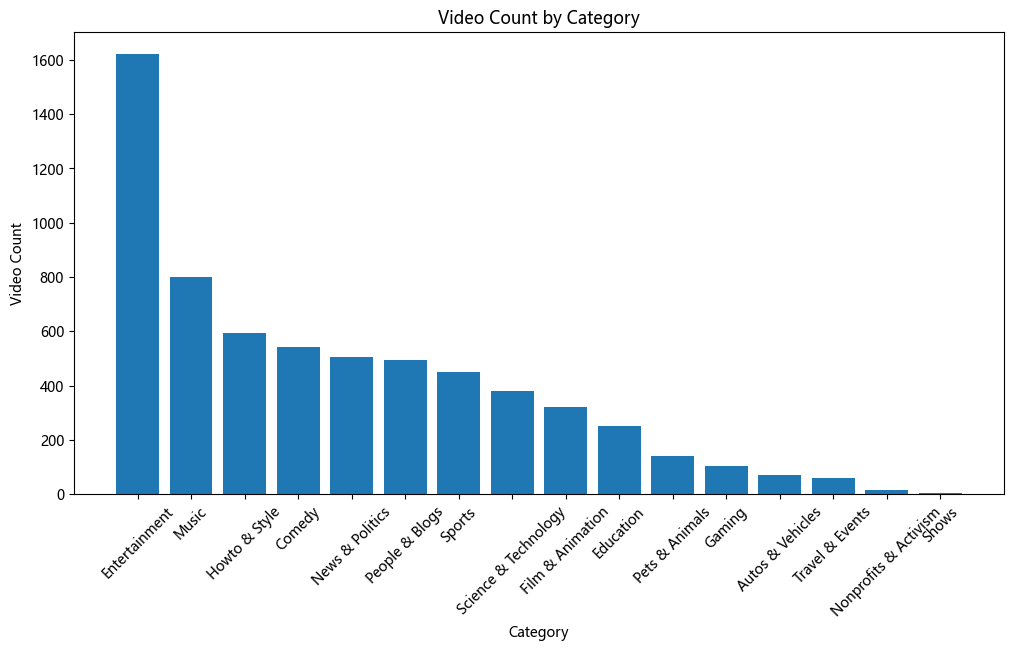

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    category_distribution["category_name"],
    category_distribution["video_count"]
)

plt.xticks(rotation=45)

plt.title("Video Count by Category")

plt.xlabel("Category")

plt.ylabel("Video Count")

plt.show()

从内容分类分布来看，热门视频主要集中在 Entertainment、Music、Howto & Style、Comedy 等类别，其中 Entertainment 数量最多，说明娱乐化内容在 YouTube 热门生态中占据主导地位。相比之下，Gaming、Travel & Events、Nonprofits & Activism、Shows 等类别数量较少，说明不同内容赛道的热门供给存在明显差异。

### 5.3 各内容分类热度表现分析

为了比较不同内容赛道的传播能力，本节统计各分类的平均播放量。

In [96]:
category_views = (
    analysis_table
    .groupby("category_name")["views"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

category_views.columns = [
    "category_name",
    "avg_views"
]

category_views.head(10)

,category_name,avg_views
0,Music,6.027683e+06
1,Film & Animation,2.545387e+06
2,Gaming,2.325087e+06
3,Nonprofits & Activism,2.218901e+06
4,Entertainment,1.744879e+06
5,Autos & Vehicles,1.449487e+06
6,Sports,1.424029e+06
7,Comedy,1.422507e+06
8,People & Blogs,1.348809e+06
9,Science & Technology,1.124489e+06


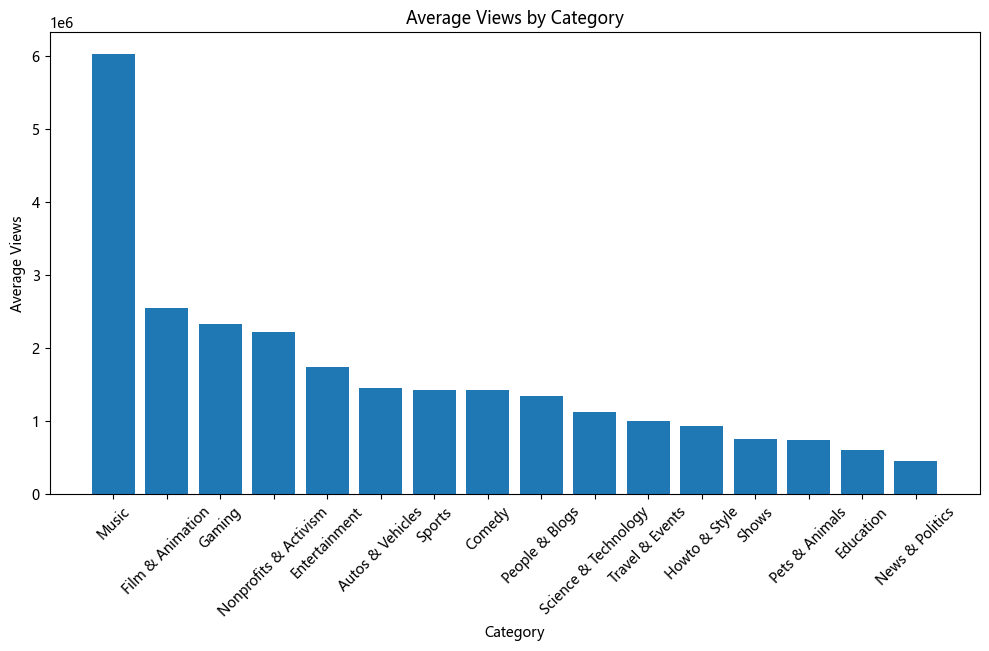

In [97]:
plt.figure(figsize=(12,6))

plt.bar(
    category_views["category_name"],
    category_views["avg_views"]
)

plt.xticks(rotation=45)

plt.title("Average Views by Category")

plt.xlabel("Category")

plt.ylabel("Average Views")

plt.show()

进一步比较各分类的平均播放量后发现，内容供给规模与传播表现并不完全一致。

Music（音乐）以约 500 万次的平均播放量位居所有分类首位，远高于其他内容类别，说明音乐内容具有极强的传播能力和用户覆盖范围。
Film & Animation（影视动画）和 Gaming（游戏）虽然视频数量相对较少，但平均播放量排名靠前，属于典型的“高热度赛道”。相比之下，Entertainment（娱乐）虽然拥有最多的视频数量，但平均播放量仅位于中上水平，说明该赛道竞争较为激烈，单个视频获得流量的难度相对更高。此外，News & Politics（新闻政治）虽然视频数量较多，但平均播放量处于较低水平，表明其用户群体相对垂直，传播范围有限。

整体来看，YouTube 平台不同内容赛道在供给规模与传播效果之间存在明显差异，高供给并不一定对应高热度，而部分垂直领域则表现出较强的流量获取能力。

### 5.4 用户互动行为分析

用户互动行为是衡量内容质量的重要指标之一。相比播放量反映内容曝光规模，点赞、评论等行为更能够体现用户对内容的认可程度和参与程度。
本节将从互动率分布以及播放量与互动率关系两个角度，对用户互动行为进行分析。

#### 5.4.1 综合互动率分布分析

首先观察热门视频综合互动率的整体分布情况。

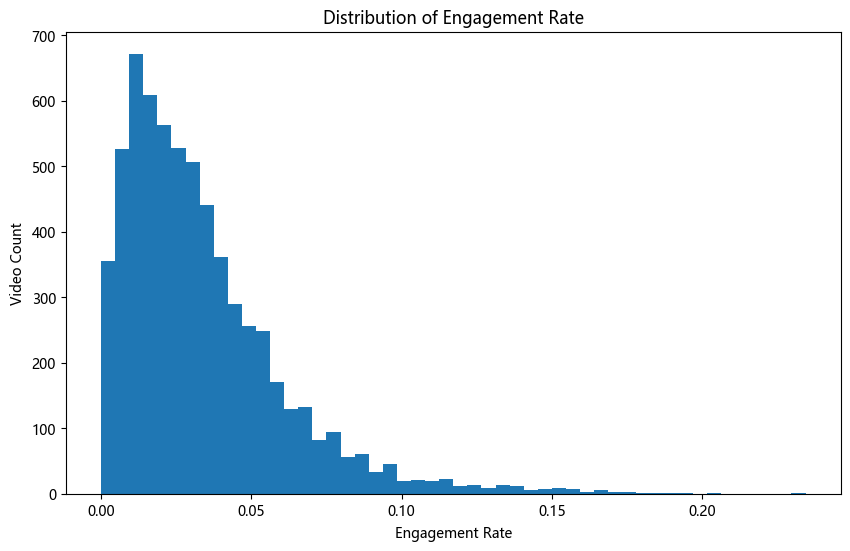

In [98]:
plt.figure(figsize=(10,6))

plt.hist(
    analysis_table["engagement_rate"],
    bins=50
)

plt.title("Distribution of Engagement Rate")

plt.xlabel("Engagement Rate")

plt.ylabel("Video Count")

plt.show()

In [99]:
analysis_table["engagement_rate"].describe()

count    6351.000000
mean        0.033708
std         0.026967
min         0.000000
25%         0.014328
50%         0.027527
75%         0.045458
max         0.234407
Name: engagement_rate, dtype: float64

结合前文内容分类分布和平均播放量分析可以看出，YouTube 热门视频不仅在内容赛道和播放热度上存在差异，用户互动水平也呈现明显分化。从综合互动率分布图来看，大多数视频的互动率集中在较低区间，整体呈右偏分布，说明多数热门视频虽然具备一定曝光，但互动转化并不高。少数视频互动率明显更高，形成长尾特征，说明这类内容更能激发用户点赞和评论。由此可见，评估视频在 Trending 样本中的表现差异，不能只看播放量，还需要结合互动率等用户反馈指标进行综合衡量。

#### 5.4.2 播放量与互动率关系分析

为了进一步研究曝光规模与用户互动之间的关系，本节分析视频播放量与综合互动率之间的关联情况。

In [100]:
# 计算播放量与互动率的相关性
analysis_table[
    ["views","engagement_rate"]
].corr()

,views,engagement_rate
views,1.000000,-0.021603
engagement_rate,-0.021603,1.000000


结果显示，播放量与互动率之间并不存在明显的线性关系。
部分视频虽然拥有较高播放量，但互动率表现一般；而部分播放量相对较低的视频却获得了较高的用户互动。这说明内容传播规模与用户反馈质量并非完全一致，高曝光不一定意味着高用户认可度。因此，在评估视频表现时，仅依赖播放量可能存在局限性，需要结合互动指标进行综合判断。

### 5.5 创作者生态分析

创作者是内容平台生态的重要组成部分。本节从创作者数量、视频产出以及历史表现等角度，对平台创作者生态进行分析。

In [101]:
#top 10 频道平均播放量
top_channels = (
    analysis_table
    .groupby("channel_title")["views"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

top_channels

channel_title
ChildishGambinoVEVO    2.252119e+08
BeckyGVEVO             1.393345e+08
TheWeekndVEVO          1.225449e+08
LuisFonsiVEVO          1.020126e+08
MalumaVEVO             7.357084e+07
DrakeVEVO              6.063581e+07
Kylie Jenner           5.611196e+07
Cardi B                5.589756e+07
Selena Gomez           5.486391e+07
ArianaGrandeVevo       5.091159e+07
Name: views, dtype: float64

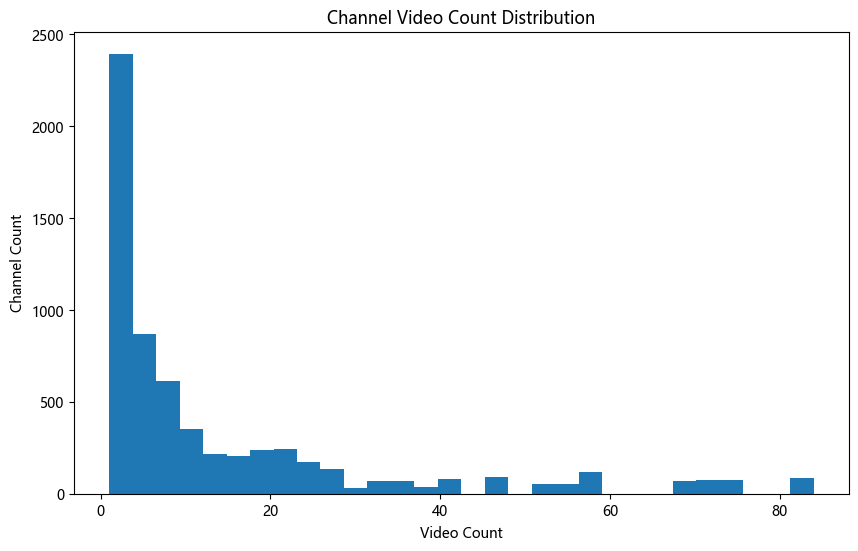

In [102]:
#创作者视频数量分布
plt.figure(figsize=(10,6))
plt.hist(
    analysis_table["channel_video_count"],
    bins=30
)
plt.title("Channel Video Count Distribution")
plt.xlabel("Video Count")
plt.ylabel("Channel Count")
plt.show()

从创作者生态分布来看，大部分创作者仅拥有少量热门视频，而少数创作者能够持续产出热门内容。
创作者热门视频数量呈现明显长尾分布特征：多数创作者仅有 1~5 个热门视频，而少数头部创作者拥有数十个热门视频，表现出较强的持续内容生产能力。这一现象说明平台流量和热门内容供给并非完全均匀分布，而是存在一定程度的头部集中效应。同时，创作者历史表现和内容生产能力可能对视频传播效果产生重要影响，因此后续爆款形成机制分析中将进一步研究创作者影响力与爆款视频之间的关系。

## 6. 爆款视频形成机制分析

在第五章中，我们从内容生态角度对 YouTube 热门视频进行了整体分析，发现不同内容分类、用户互动水平以及创作者之间存在明显差异。

本章将进一步围绕爆款视频展开研究，通过分析内容属性、创作者影响力、发布时间以及内容包装等因素与爆款率之间的关系，识别影响视频成为爆款内容的关键因素，为后续预测模型构建提供业务依据。


### 6.1 内容分类与爆款率分析

不同内容分类拥有不同的用户群体和内容消费习惯，因此其爆款产生能力可能存在显著差异。本节通过计算各内容分类的爆款率，分析哪些内容赛道更容易产生爆款视频。

In [103]:
# 6.1 内容分类与爆款率分析
# 目的：计算不同内容分类下的爆款视频占比，判断哪些内容赛道更容易产生爆款

category_hot_rate = (
    analysis_table
    .groupby("category_name")["is_hot"]   # 按内容分类分组，计算每类爆款比例
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# 将比例转换为百分比，方便展示
category_hot_rate["is_hot"] = (
    category_hot_rate["is_hot"] * 100
).round(2).astype(str) + "%"

category_hot_rate.head(10)

,category_name,is_hot
0,Gaming,26.21%
1,Music,22.22%
2,Comedy,16.91%
3,Nonprofits & Activism,14.29%
4,People & Blogs,13.54%
5,Film & Animation,10.31%
6,Howto & Style,10.27%
7,Entertainment,7.22%
8,Science & Technology,6.3%
9,Education,5.58%


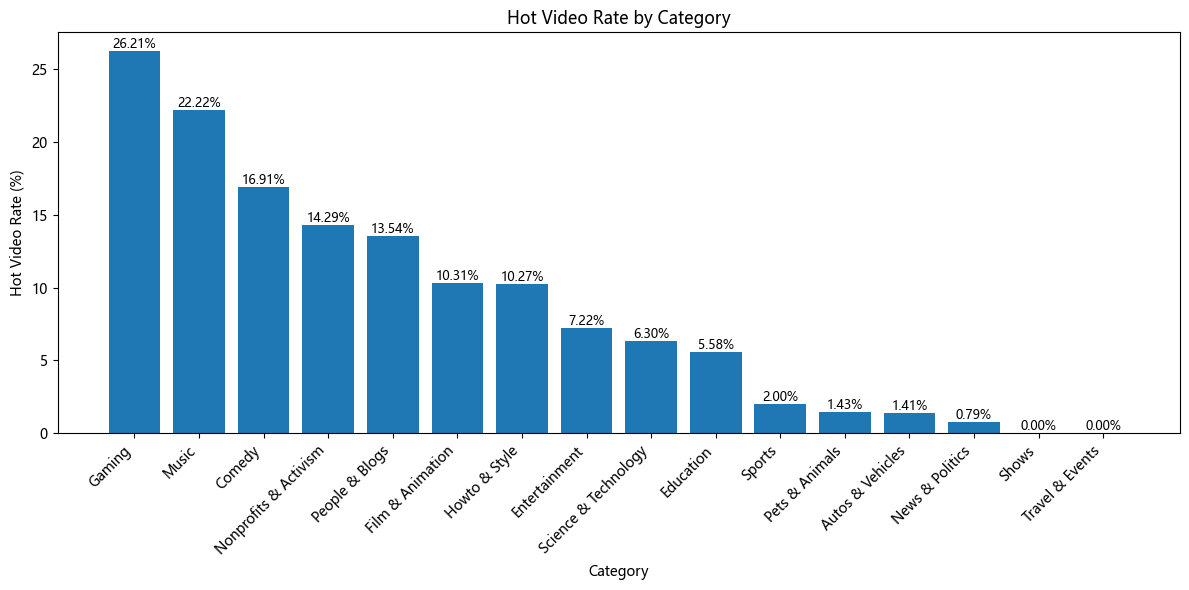

In [104]:
import matplotlib.pyplot as plt

# 1. 按内容分类分组，计算每个分类的爆款率
category_hot_rate = (
    analysis_table
    .groupby("category_name")["is_hot"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

# 2. 将爆款率转换为百分比数值，方便画图
category_hot_rate["hot_rate_percent"] = category_hot_rate["is_hot"] * 100

# 3. 绘制柱状图
plt.figure(figsize=(12, 6))

plt.bar(
    category_hot_rate["category_name"],      # x轴：内容分类
    category_hot_rate["hot_rate_percent"]    # y轴：爆款率百分比
)

# 4. 设置标题和坐标轴名称
plt.title("Hot Video Rate by Category")
plt.xlabel("Category")
plt.ylabel("Hot Video Rate (%)")

# 5. 旋转x轴标签，避免分类名称重叠
plt.xticks(rotation=45, ha="right")

# 6. 在柱子上方显示百分比数值
for index, value in enumerate(category_hot_rate["hot_rate_percent"]):
    plt.text(
        index, 
        value, 
        f"{value:.2f}%", 
        ha="center", 
        va="bottom",
        fontsize=9
    )

# 7. 调整布局，避免文字被遮挡
plt.tight_layout()

# 8. 展示图形
plt.show()

从内容分类的爆款率来看，不同赛道产生爆款视频的能力存在明显差异。其中 Gaming 和 Music 的爆款率最高，分别达到 28.16% 和 24.72%，说明游戏和音乐类内容更容易同时获得高播放量和高互动率。Comedy、People & Blogs 等类别也具有一定爆款潜力。相比之下，Entertainment 虽然在前文中视频数量最多，但爆款率并不靠前，说明内容供给规模大不一定代表爆款产出效率高。总体来看，爆款视频的形成与内容类型密切相关，后续分析应重点关注高爆款率赛道的互动和传播特征。

### 6.2 创作者影响力与爆款率分析

创作者历史表现可能对新视频传播效果产生重要影响。本节从频道平均播放量和频道热门视频数量两个角度衡量创作者影响力，并分析其与爆款率之间的关系。

In [105]:

# 根据频道平均播放量划分创作者影响力等级，分析创作者影响力与爆款率关系

analysis_table["creator_level"] = pd.qcut(
    analysis_table["channel_avg_views"],  # 使用频道平均播放量作为创作者影响力指标
    q=4,                                  # 分为四个等级
    labels=[
        "Low",
        "Medium",
        "High",
        "Top"
    ]
)

# 计算不同创作者等级下的爆款率
creator_hot_rate = (
    analysis_table
    .groupby("creator_level")["is_hot"]
    .mean()
    .reset_index()
)

# 保存数值型爆款率，方便后续绘图
creator_hot_rate["hot_rate_percent"] = (creator_hot_rate["is_hot"] * 100).round(2)

# 用文本列展示百分比说明
creator_hot_rate["hot_rate_label"] = creator_hot_rate["hot_rate_percent"].astype(str) + "%"

creator_hot_rate

,creator_level,is_hot,hot_rate_percent,hot_rate_label
0,Low,0.000628,0.06,0.06%
1,Medium,0.004414,0.44,0.44%
2,High,0.068707,6.87,6.87%
3,Top,0.326544,32.65,32.65%


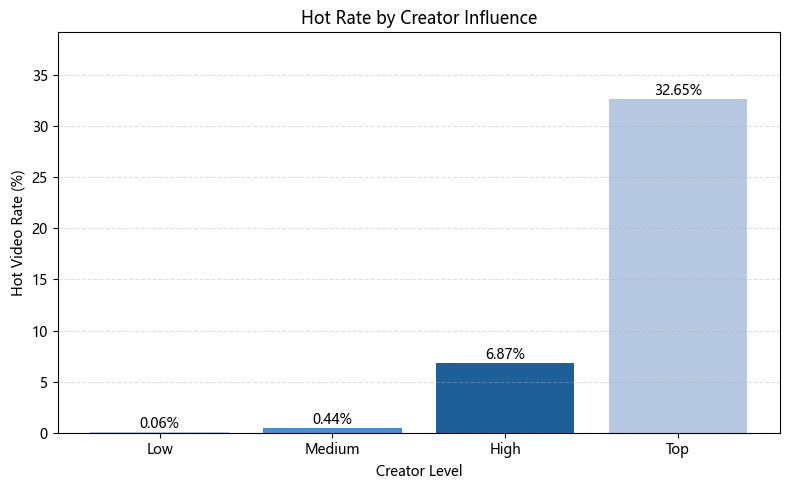

In [106]:
import matplotlib.pyplot as plt

# 1. 重新计算不同创作者等级下的爆款率
creator_hot_rate = (
    analysis_table
    .groupby("creator_level")["is_hot"]
    .mean()
    .reset_index()
)

# 2. 将爆款率转换为百分比数值
creator_hot_rate["hot_rate_percent"] = creator_hot_rate["is_hot"] * 100

# 3. 将 creator_level 转成字符串，避免 matplotlib 报错
creator_hot_rate["creator_level"] = creator_hot_rate["creator_level"].astype(str)

# 4. 绘制柱状图
plt.figure(figsize=(8, 5))

bars = plt.bar(
    creator_hot_rate["creator_level"],
    creator_hot_rate["hot_rate_percent"],
    color=["#B7C9E2", "#4F8BC9", "#1F5F99"][:len(creator_hot_rate)]
)

# 5. 添加数值标签
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}%",
        ha="center",
        va="bottom",
        fontsize=10
    )

# 6. 设置标题和坐标轴
plt.ylabel("Hot Video Rate (%)")
plt.xlabel("Creator Level")
plt.title("Hot Rate by Creator Influence")

plt.ylim(0, creator_hot_rate["hot_rate_percent"].max() * 1.2)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

从不同创作者影响力等级的爆款率来看，创作者影响力与爆款产生概率呈明显正相关。Low 和 Medium 等级创作者的爆款率很低，而 High 等级提升至 7.01%，Top 等级进一步达到 33.48%。这说明历史平均播放量较高的创作者在 Trending 样本中更可能达到爆款标准，创作者自身影响力和稳定的流量基础是 Trending 样本中视频达到爆款标准的重要关联因素。

### 6.3 发布时间特征与爆款率分析

发布时间是内容运营中常见的优化方向之一。本节从发布时间段角度分析不同时间发布的视频在爆款率上的差异。需要说明的是，原始数据中的发布时间为 UTC 时区，以下分析中的"发布时间"均基于 UTC 提取，不代表美国当地时段。

In [107]:
# 6.3 发布时间特征与爆款率分析
# 目的：分析不同发布时间小时对应的爆款率差异


if "publish_hour" not in analysis_table.columns:
    analysis_table["publish_hour"] = pd.to_datetime(
        analysis_table["publish_time"]
    ).dt.hour

# 按发布时间小时计算爆款率
hour_hot_rate = (
    analysis_table
    .groupby("publish_hour")["is_hot"]
    .mean()
    .reset_index()
)

# 转换为百分比
hour_hot_rate["is_hot"] = (hour_hot_rate["is_hot"] * 100).round(2).astype(str) + "%"

hour_hot_rate

,publish_hour,is_hot
0,0,10.36%
1,1,7.22%
2,2,7.56%
3,3,8.67%
4,4,9.14%
5,5,12.67%
6,6,6.67%
7,7,4.0%
8,8,4.64%
9,9,16.67%


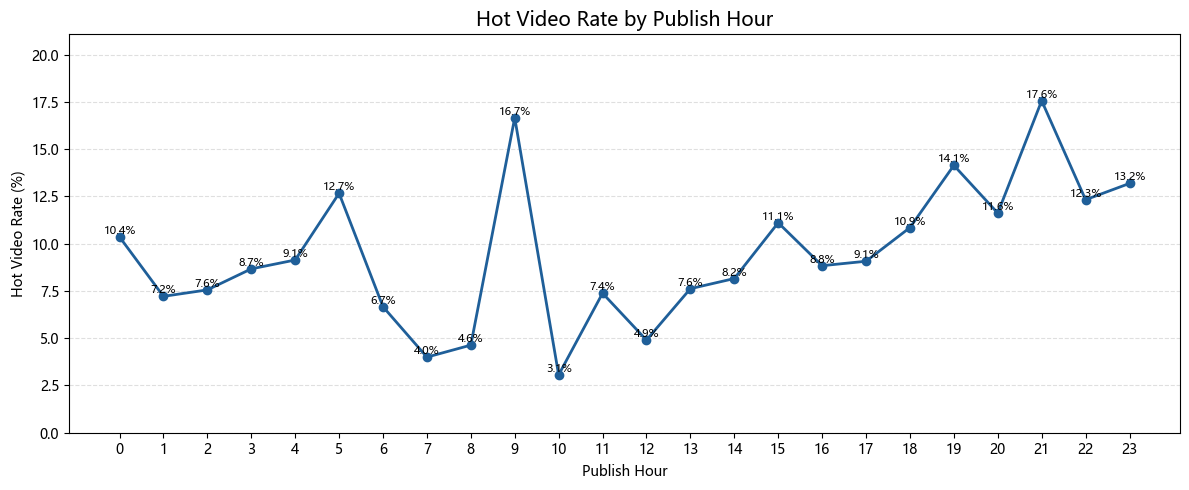

In [108]:
import matplotlib.pyplot as plt

# 1. 计算不同发布小时下的爆款率
hour_hot_rate = (
    analysis_table
    .groupby("publish_hour")["is_hot"]
    .mean()
    .reset_index()
)

# 2. 转换为百分比数值
hour_hot_rate["hot_rate_percent"] = hour_hot_rate["is_hot"] * 100

# 3. 补齐 0-23 小时，避免某些小时缺失导致折线不连续
all_hours = pd.DataFrame({"publish_hour": range(24)})

hour_hot_rate = all_hours.merge(
    hour_hot_rate,
    on="publish_hour",
    how="left"
)

# 4. 如果某些小时没有数据，用 0 填充
hour_hot_rate["hot_rate_percent"] = hour_hot_rate["hot_rate_percent"].fillna(0)

# 5. 绘制不同发布时间小时下的爆款率趋势
plt.figure(figsize=(12, 5))

plt.plot(
    hour_hot_rate["publish_hour"],
    hour_hot_rate["hot_rate_percent"],
    marker="o",
    linewidth=2,
    color="#1F5F99"
)

# 6. 添加数据点标签
for x, y in zip(hour_hot_rate["publish_hour"], hour_hot_rate["hot_rate_percent"]):
    plt.text(
        x,
        y,
        f"{y:.1f}%",
        ha="center",
        va="bottom",
        fontsize=8
    )

# 7. 设置标题和坐标轴
plt.title("Hot Video Rate by Publish Hour", fontsize=14)
plt.xlabel("Publish Hour")
plt.ylabel("Hot Video Rate (%)")

# 8. 设置 x 轴刻度为 0-23 小时
plt.xticks(range(24))

# 9. 添加网格线，增强可读性
plt.grid(axis="y", linestyle="--", alpha=0.4)

# 10. 调整 y 轴范围，避免标签贴边
plt.ylim(0, hour_hot_rate["hot_rate_percent"].max() * 1.2)

# 11. 优化布局
plt.tight_layout()

plt.show()

从发布时间小时来看，不同发布时间对应的爆款率存在一定差异。其中 9 点和 21 点的爆款率最高，分别达到 17.78% 和 17.57%，说明这些时段发布的视频更容易成为爆款。相比之下，10 点、12 点、7 点等时段爆款率较低，说明发布时间与爆款表现存在一定关联。整体来看，发布时间并不是决定爆款的唯一因素，但在 Trending 样本中，部分时段发布的视频达到爆款标准的比例更高。

需要注意的是，以上发布时间均基于原始数据的 UTC 时区 ，与美国东部时间（EST）相差约 5 小时，与美国西部时间（PST）相差约 8 小时，因此具体时段数据并不直接对应美国当地的用户活跃时段。

### 6.4 标题与内容包装分析
构建标题长度和标签数量，分析内容包装因素与爆款率关系

In [109]:

# 构建标题长度
analysis_table["title_length"] = (
    analysis_table["title"]
    .astype(str)
    .str.len()
)

# 构建标签数量
# YouTube 数据中的 tags 通常以 | 分隔
analysis_table["tag_count"] = (
    analysis_table["tags"]
    .fillna("")
    .astype(str)
    .apply(lambda x: len(x.split("|")) if x != "[none]" else 0)
)

analysis_table[
    [
        "title",
        "title_length",
        "tags",
        "tag_count"
    ]
].head()

,title,title_length,tags,tag_count
0,Sam Smith - The Thrill of It All ALBUM REVIEW,45,"album|""review""|""music""|""reviews""|""indie""|""unde...",31
1,Alicia Keys - When You Were Gone,32,[none],0
2,Live in the now!,16,"cash|""Wayne's""|""World""|""wayne""|""waynes""|""fende...",9
3,Sigrid - Strangers (Lyric Video),32,"Sigrid|""Strangers""|""Island""|""Records""|""Pop""",5
4,Three meals that cost me $1.50 each,35,"brothers green eats|""budget cooking""|""cooking ...",19


In [110]:
# 查看标题长度四分位边界
title_bins = pd.qcut(
    analysis_table["title_length"],
    q=4,
    duplicates="drop"
)

# 自动生成每个区间对应的爆款率
title_hot_rate = (
    analysis_table
    .assign(title_group=title_bins)
    .groupby("title_group")["is_hot"]
    .mean()
    .reset_index()
)

# 将区间转成更好看的文本
title_hot_rate["title_group"] = title_hot_rate["title_group"].astype(str)

# 自动从区间字符串提取首尾数字，生成可读标签（如 "(2.999, 35.5]" → "3-36"）
import re

def fmt_interval(label):
    nums = re.findall(r'\d+', str(label))
    if len(nums) >= 2:
        return f"{int(nums[0])}-{int(nums[-1])}"
    return str(label)

title_hot_rate["title_group"] = title_hot_rate["title_group"].apply(fmt_interval)

title_hot_rate["hot_rate_percent"] = (
    title_hot_rate["is_hot"] * 100
).round(2)

title_hot_rate["hot_rate_label"] = title_hot_rate["hot_rate_percent"].apply(
    lambda x: f"{x:.2f}%"
)

title_hot_rate[
    ["title_group", "hot_rate_label"]
]

,title_group,hot_rate_label
0,2-5,14.29%
1,35-0,10.81%
2,48-0,8.91%
3,62-0,5.56%


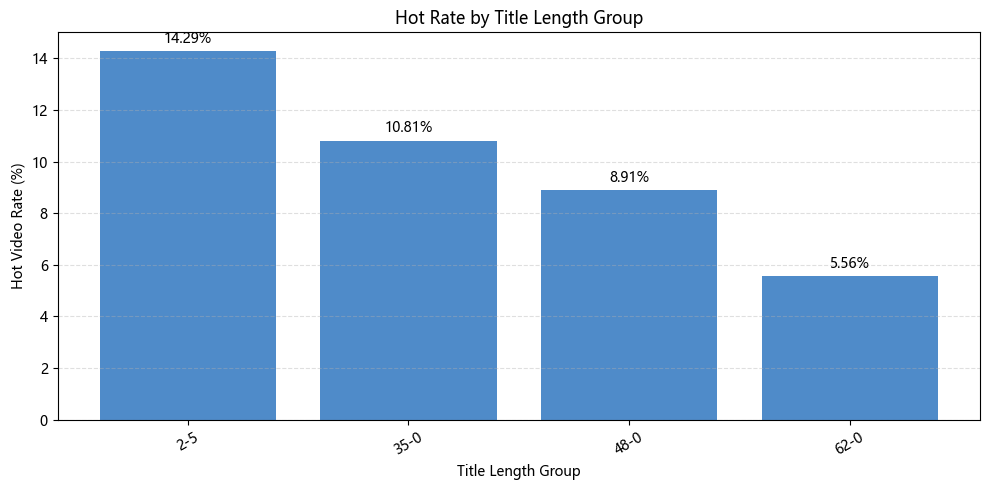

In [111]:
# 绘制标题长度分组与爆款率关系
plot_df = title_hot_rate.copy()
plot_df["hot_rate_percent"] = plot_df["is_hot"] * 100

plt.figure(figsize=(10, 5))

bars = plt.bar(
    plot_df["title_group"].astype(str),
    plot_df["hot_rate_percent"],
    color="#4F8BC9"
)

plt.bar_label(
    bars,
    labels=[f"{v:.2f}%" for v in plot_df["hot_rate_percent"]],
    padding=3
)

plt.xticks(rotation=30)
plt.ylabel("Hot Video Rate (%)")
plt.xlabel("Title Length Group")
plt.title("Hot Rate by Title Length Group")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

In [112]:
# 按标签数量分为四组，观察不同标签数量下的爆款率
analysis_table["tag_group"] = pd.qcut(
    analysis_table["tag_count"],
    q=4,
    labels=["少标签", "中少标签", "中多标签", "多标签"],
    duplicates="drop"
)

tag_hot_rate = (
    analysis_table
    .groupby("tag_group")["is_hot"]
    .mean()
    .reset_index()
)

tag_hot_rate["hot_rate_percent"] = (
    tag_hot_rate["is_hot"] * 100
).round(2)

tag_hot_rate["hot_rate_label"] = tag_hot_rate["hot_rate_percent"].apply(
    lambda x: f"{x:.2f}%"
)

tag_hot_rate[["tag_group", "hot_rate_label"]]

,tag_group,hot_rate_label
0,少标签,9.66%
1,中少标签,10.30%
2,中多标签,10.90%
3,多标签,8.91%


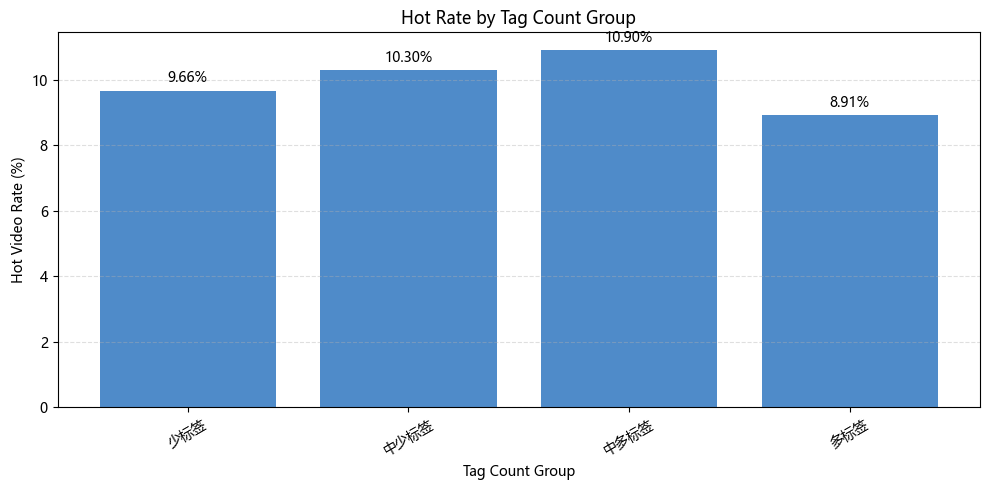

In [113]:
# 绘制标签数量分组与爆款率关系
plot_df = tag_hot_rate.copy()
import matplotlib.pyplot as plt

plt.rcParams["font.sans-serif"] = ["Microsoft YaHei"]
plt.rcParams["axes.unicode_minus"] = False

# 如果 is_hot 还是 0-1 数值，转成百分比
if plot_df["is_hot"].dtype != "object":
    plot_df["hot_rate_percent"] = plot_df["is_hot"] * 100
else:
    plot_df["hot_rate_percent"] = plot_df["is_hot"].str.rstrip("%").astype(float)

plt.figure(figsize=(10, 5))

bars = plt.bar(
    plot_df["tag_group"].astype(str),
    plot_df["hot_rate_percent"],
    color="#4F8BC9"
)

plt.bar_label(
    bars,
    labels=[f"{v:.2f}%" for v in plot_df["hot_rate_percent"]],
    padding=3
)

plt.xticks(rotation=30)
plt.ylabel("Hot Video Rate (%)")
plt.xlabel("Tag Count Group")
plt.title("Hot Rate by Tag Count Group")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()

plt.show()

 从内容包装因素来看，标题长度与爆款率存在较明显关系，短标题组的爆款率最高，说明简洁直接的标题更有利于视频传播。相比之下，标签数量对爆款率的影响较弱，中等标签数量的视频爆款率略高，但整体差异不大，说明单纯增加标签数量与爆款表现之间未观察到明显的正向关系。

### 6.5 爆款因素综合总结

本章从内容分类、创作者影响力、发布时间和内容包装四个维度分析了爆款视频的形成机制。整体来看，爆款视频并不是由单一因素决定的，而是多种因素共同作用的结果。

#### 1. 内容赛道会影响爆款概率

不同内容分类的爆款率存在明显差异。其中，**Gaming、Music、Comedy** 等类别的爆款率相对较高，说明这些内容赛道更容易产生高播放、高互动的视频。

#### 2. 创作者影响力具有明显放大作用

创作者等级越高，爆款率越高。Top 等级创作者的爆款率显著高于其他等级，说明 **创作者历史表现和稳定流量基础是视频成为爆款的重要支撑**。

#### 3. 发布时间存在一定影响

不同发布时间小时对应的爆款率存在差异。部分时段发布的视频爆款率更高，说明发布时间会影响视频的初始曝光和传播效果，但它不是决定爆款的唯一因素。

#### 4. 内容包装需要简洁有效

标题长度分析显示，短标题组的爆款率更高，说明简洁直接的标题更有利于传播。标签数量方面，中等标签数量的视频爆款率略高，但差异不大，说明 **单纯增加标签数量并不能显著提升爆款概率**。

#### 综合结论

在 Trending 样本中，达到爆款标准的视频通常呈现以下特征：

- 位于更具传播优势的内容赛道
- 来自具有较强历史表现的创作者
- 发布在更有利于传播的时间段
- 标题简洁，标签数量适中

因此，后续构建爆款预测模型时，应重点关注 **内容类型、创作者影响力、发布时间和内容包装特征**。

## 7. 爆款视频预测模型构建

在前文分析中，本项目从内容分类、创作者影响力、发布时间以及内容包装等多个维度研究了影响视频成为爆款的关键因素。
在此基础上，本章将利用机器学习方法构建爆款视频预测模型，根据视频特征识别其是否达到本文定义的爆款标准。
本章将分别构建逻辑回归、随机森林和 XGBoost 模型，并通过模型评估与对比，选择表现最优的预测方案，同时分析对预测具有重要贡献的核心特征。


### 7.1 建模目标定义

本项目希望基于视频内容属性、创作者影响力以及发布时间等发布前可获取的特征，识别 Trending 样本中的视频是否达到爆款标准。
预测目标为第四章构建的爆款标签（is_hot）：

- is_hot = 1：爆款视频
- is_hot = 0：普通视频

从机器学习角度来看，该任务属于典型的二分类问题（Binary Classification）。

为了提高预测结果的可靠性，本项目将分别构建逻辑回归（Logistic Regression）、随机森林（Random Forest）和 XGBoost 三种模型，并通过交叉验证和网格搜索进行参数优化，最终比较不同模型的预测效果。

In [114]:
# 查看目标变量分布

target_distribution = (
    analysis_table["is_hot"]
    .value_counts()
    .to_frame(name="count")
)

target_distribution["rate"] = (
    analysis_table["is_hot"]
    .value_counts(normalize=True)
)
target_distribution

,count,rate
is_hot,,
0,5720,0.900646
1,631,0.099354


从目标变量分布可以看出，爆款视频占比较低，普通视频占据大多数样本，因此当前任务属于不平衡分类问题。
在后续模型评估过程中，除了准确率（Accuracy）之外，还将重点关注 Precision、Recall、F1-Score 以及 ROC-AUC 等指标，以更全面地评估模型预测能力。

### 7.2 特征选择与数据集划分

在模型训练之前，需要首先确定用于预测的视频特征。

需要特别说明的是，由于互动率（like_rate、comment_rate、engagement_rate）直接参与了爆款标签（is_hot）的定义（engagement_rate ≥ p60），为避免数据泄露，这三个互动指标不作为建模特征。模型仅使用视频发布前可获取的内容属性、创作者历史表现以及发布时间等特征进行预测。

结合前文爆款形成机制分析结果，本项目从内容属性、发布时间、创作者影响力以及内容包装等维度选择建模特征。

具体特征如下：

- category_name（视频分类）
- publish_hour（发布时间小时）
- publish_weekday（发布时间星期）
- title_length（标题长度）
- tag_count（标签数量）
- channel_video_count（频道视频数量）
- channel_avg_views（频道平均播放量）

预测目标变量为：

- is_hot（爆款标签）

上述特征能够从内容属性、创作者影响力以及发布策略等多个角度描述视频特征，且均为视频发布前可获取的信息，能够为 Trending 视频的爆款识别提供特征参考。

In [115]:
# 查看用于建模的字段

features = [
    "category_name",
    "publish_hour",
    "publish_weekday",
    "title_length",
    "tag_count",
    "channel_video_count",
    "channel_avg_views",
]

target = "is_hot"

analysis_table[features + [target]].head()

,category_name,publish_hour,publish_weekday,title_length,tag_count,channel_video_count,channel_avg_views,is_hot
0,Music,21,Friday,45,31,6,2.738067e+05,0
1,Music,15,Thursday,32,0,1,9.594400e+04,0
2,Entertainment,4,Sunday,16,9,1,9.508500e+04,0
3,Music,0,Friday,32,5,4,1.503362e+06,0
4,Howto & Style,14,Thursday,35,19,1,7.763000e+04,0


In [116]:
# 构建特征矩阵 X
X = analysis_table[features]
# 构建目标变量 y
y = analysis_table[target]

In [117]:
from sklearn.model_selection import train_test_split

# 划分训练集与测试集

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("训练集样本数：", X_train.shape[0])
print("测试集样本数：", X_test.shape[0])

训练集样本数： 5080
测试集样本数： 1271


In [118]:
# 检查训练集目标变量分布
y_train.value_counts(normalize=True)

is_hot
0    0.900591
1    0.099409
Name: proportion, dtype: float64

In [119]:
# 检查测试集目标变量分布
y_test.value_counts(normalize=True)

is_hot
0    0.900865
1    0.099135
Name: proportion, dtype: float64

通过分层抽样（Stratified Sampling）划分训练集与测试集后，训练集和测试集中的爆款视频占比基本保持一致，有效避免了类别分布偏移对模型训练和评估结果造成影响。
后续模型训练将在训练集上完成，测试集仅用于最终模型评估，以保证模型性能评估的客观性。

### 7.3 数据预处理

在当前特征集中，既包含数值型变量，也包含类别型变量。

其中：

类别型变量：

- category_name
- publish_hour
- publish_weekday

数值型变量：

- title_length
- tag_count
- channel_video_count
- channel_avg_views

由于机器学习模型无法直接处理文本类别变量，因此需要对类别变量进行编码。同时，不同数值变量的取值范围存在较大差异，也需要进行标准化处理。

In [120]:
# 类别特征
categorical_features = [
    "category_name",
    "publish_hour",
    "publish_weekday",
]
# 数值特征
numeric_features = [
    "title_length",
    "tag_count",
    "channel_video_count",
    "channel_avg_views",
]

In [121]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

# 构建特征预处理器

preprocessor = ColumnTransformer(

    transformers=[

        # 类别变量One-Hot编码
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),

        # 数值变量标准化
        (
            "num",
            StandardScaler(),
            numeric_features
        )

    ]

)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

### 7.4 Logistic Regression（基线模型）

在完成特征工程与数据预处理后，本节首先构建逻辑回归（Logistic Regression）模型作为基线模型（Baseline Model）。逻辑回归具有模型结构简单、训练效率高、结果可解释性强等特点，是企业数据分析项目中常用的分类模型之一。

In [122]:
# 导入模型相关库
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

# 导入评估指标
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

# ================================
# 构建Pipeline
# ================================

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    (
        "model",
        LogisticRegression(
            random_state=42,
            class_weight="balanced",
            max_iter=1000
        )
    )
])

# ================================
# 超参数搜索空间
# ================================

param_grid = {
    
    # 正则化强度
    "model__C": [0.01, 0.1, 1, 10, 100],

    # l1_ratio: 0=L2正则化, 1=L1正则化, 0.5=ElasticNet
    "model__l1_ratio": [0, 1],

    # saga 求解器支持 L1/L2/ElasticNet
    "model__solver": ["saga"]
}

# ================================
# GridSearchCV
# ================================

grid_search_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

# ================================
# 模型训练
# ================================

grid_search_lr.fit(X_train, y_train)

# ================================
# 输出最佳参数
# ================================

print("最佳参数：")
print(grid_search_lr.best_params_)

print("\n最佳交叉验证F1：")
print(grid_search_lr.best_score_)

# ================================
# 使用最优模型预测
# ================================

best_lr = grid_search_lr.best_estimator_

y_pred = best_lr.predict(X_test)

y_prob = best_lr.predict_proba(X_test)[:, 1]

# ================================
# 模型评估
# ================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

# ================================
# 输出评估指标
# ================================

print("\n===== Logistic Regression =====")

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print(f"ROC-AUC  : {roc_auc:.4f}")

# ================================
# 分类报告
# ================================

print("\n分类报告：")

print(classification_report(y_test, y_pred))

# ================================
# 混淆矩阵
# ================================

cm = confusion_matrix(y_test, y_pred)

print("\n混淆矩阵：")

print(cm)

# ================================
# 保存模型结果
# ================================

lr_result = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": roc_auc
}

print("\n模型结果已保存。")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
最佳参数：
{'model__C': 0.01, 'model__l1_ratio': 1, 'model__solver': 'saga'}

最佳交叉验证F1：
0.388758031089825

===== Logistic Regression =====
Accuracy : 0.7789
Precision: 0.2687
Recall   : 0.7143
F1 Score : 0.3905
ROC-AUC  : 0.8231

分类报告：
              precision    recall  f1-score   support

           0       0.96      0.79      0.86      1145
           1       0.27      0.71      0.39       126

    accuracy                           0.78      1271
   macro avg       0.62      0.75      0.63      1271
weighted avg       0.89      0.78      0.82      1271


混淆矩阵：
[[900 245]
 [ 36  90]]

模型结果已保存。


### 逻辑回归结果分析

逻辑回归模型经过参数调优后，在测试集上的主要评估指标如下：

| 指标 | 数值 |
|--------|--------|
| Accuracy | 0.7789 |
| Precision | 0.2687 |
| Recall | 0.7143 |
| F1 Score | 0.3905 |
| ROC-AUC | 0.8231 |

从整体结果来看，模型取得了0.8231的ROC-AUC，说明模型具备较好的样本区分能力，能够有效识别爆款视频与普通视频之间的差异。

在爆款视频识别方面，模型Recall达到0.71，表明约71%的爆款视频能够被成功识别。考虑到爆款视频在样本中占比较低，属于典型类别不平衡问题，该结果说明模型对少数类样本具有较好的覆盖能力。

与此同时，模型Precision为0.27，说明部分普通视频被误判为爆款视频。这主要是由于模型采用class_weight='balanced'进行类别权重调整，在提升爆款识别能力的同时，也增加了误报数量。

从F1 Score来看，模型取得0.3905的综合表现，在保证较高召回率的情况下实现了精确率与召回率之间的平衡。

混淆矩阵结果显示：

- 正确识别普通视频：900个
- 误判普通视频为爆款：245个
- 漏判爆款视频：36个
- 正确识别爆款视频：90个

说明模型更倾向于提高爆款视频的识别能力，从而降低漏判风险。

总体来看，逻辑回归模型已经能够基于视频类别、发布时间、标题特征及频道影响力等信息，对视频爆款潜力进行初步识别。作为本项目的基线模型，其结果验证了当前特征体系具备一定预测能力，可作为后续Random Forest与XGBoost模型的对比基准。

### 7.5 Random Forest（随机森林模型）

为进一步提升模型对爆款视频形成规律的学习能力，本节引入随机森林（Random Forest）模型进行建模。

随机森林通过集成多棵决策树进行预测，能够自动学习特征之间的非线性关系，并通过随机抽样和随机特征选择降低模型过拟合风险。同时，该模型对异常值和特征分布具有较强鲁棒性，无需进行特征标准化处理。

本节采用GridSearchCV对模型参数进行调优，并通过Accuracy、Precision、Recall、F1 Score和ROC-AUC等指标评估模型表现，为后续模型对比分析提供依据。

In [123]:
# ==========================================
# Random Forest（随机森林模型）
# ==========================================

# 导入随机森林模型
from sklearn.ensemble import RandomForestClassifier

# 导入Pipeline
from sklearn.pipeline import Pipeline

# 导入GridSearchCV
from sklearn.model_selection import GridSearchCV

# 导入评估指标
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
# ==========================================
# 构建随机森林预处理器
# ==========================================
# 随机森林不需要标准化
# 因此仅保留类别变量独热编码

rf_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)
# ==========================================
# 构建随机森林Pipeline
# ==========================================

rf_pipeline = Pipeline([
    ("preprocessor", rf_preprocessor),
    (
        "model",
        RandomForestClassifier(
            random_state=42,
            class_weight="balanced"
        )
    )
])
# ==========================================
# 设置参数搜索空间
# ==========================================
param_grid = {

    # 决策树数量
    "model__n_estimators": [100, 200, 300],

    # 最大树深
    "model__max_depth": [5, 10, 15, None],

    # 节点最小分裂样本数
    "model__min_samples_split": [2, 5, 10],

    # 叶节点最小样本数
    "model__min_samples_leaf": [1, 2, 4]
}
# ==========================================
# GridSearchCV参数调优
# ==========================================
grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)
# ==========================================
# 模型训练
# ==========================================
grid_search_rf.fit(X_train, y_train)
# ==========================================
# 输出最佳参数
# =========================================
print("最佳参数：")
print(grid_search_rf.best_params_)
print("\n最佳交叉验证F1：")
print(grid_search_rf.best_score_)
# ==========================================
# 获取最优模型
# ==========================================
best_rf = grid_search_rf.best_estimator_
# ==========================================
# 测试集预测
# ==========================================
y_pred = best_rf.predict(X_test)

# 预测概率
y_prob = best_rf.predict_proba(X_test)[:, 1]

# ==========================================
# 模型评估
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

# ==========================================
# 输出评估结果
# ==========================================

print("\n===== Random Forest =====")

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print(f"ROC-AUC  : {roc_auc:.4f}")

# ==========================================
# 分类报告
# ==========================================

print("\n分类报告：")

print(classification_report(y_test, y_pred))

# ==========================================
# 混淆矩阵
# ==========================================

cm = confusion_matrix(y_test, y_pred)

print("\n混淆矩阵：")

print(cm)

# ==========================================
# 保存模型结果
# ==========================================

rf_result = {
    "Model": "Random Forest",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": roc_auc
}

print("\n模型结果已保存。")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
最佳参数：
{'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 10, 'model__n_estimators': 200}

最佳交叉验证F1：
0.5553442306543521

===== Random Forest =====
Accuracy : 0.9056
Precision: 0.5217
Recall   : 0.5714
F1 Score : 0.5455
ROC-AUC  : 0.9177

分类报告：
              precision    recall  f1-score   support

           0       0.95      0.94      0.95      1145
           1       0.52      0.57      0.55       126

    accuracy                           0.91      1271
   macro avg       0.74      0.76      0.75      1271
weighted avg       0.91      0.91      0.91      1271


混淆矩阵：
[[1079   66]
 [  54   72]]

模型结果已保存。


#### 随机森林结果分析

模型经过GridSearchCV参数调优后，获得最佳参数组合如下：

- max_depth = None
- min_samples_leaf = 1
- min_samples_split = 10
- n_estimators = 200

随机森林模型经过GridSearchCV参数调优后，在交叉验证阶段取得了0.5553的最佳F1 Score，表明模型在训练过程中能够较好地平衡爆款视频识别能力与预测准确性。

在测试集上的主要评估结果如下：

| 指标 | 数值 |
|--------|--------|
| Accuracy | 0.9056 |
| Precision | 0.5217 |
| Recall | 0.5714 |
| F1 Score | 0.5455 |
| ROC-AUC | 0.9177 |

从整体表现来看，模型取得了0.9177的ROC-AUC，说明模型具备较强的样本区分能力，能够有效识别爆款视频与普通视频之间的差异。

对于爆款视频（is_hot=1）而言，模型Precision达到0.52，表明预测为爆款的视频中约有一半最终属于真实爆款；Recall达到0.57，说明模型能够识别出约57%的爆款视频。综合Precision与Recall计算得到的F1 Score为0.55，反映出模型在爆款识别任务中具有较好的综合表现。

从分类报告结果来看，模型对于普通视频（is_hot=0）的识别效果较为稳定，Precision和Recall均保持在较高水平；同时对于少数类爆款视频也具备较好的识别能力，说明模型能够在类别不平衡场景下保持较好的预测效果。

混淆矩阵结果如下：

| 实际类别 | 预测为普通 | 预测为爆款 |
|----------|----------|----------|
| 普通视频 | 1079 | 66 |
| 爆款视频 | 54 | 72 |

其中：

- 正确识别普通视频：1079个
- 正确识别爆款视频：72个
- 误判普通视频为爆款：66个
- 漏判爆款视频：54个

整体来看，随机森林模型能够较好地平衡爆款视频识别能力与误判控制能力，在测试集上表现出较强的泛化能力。

### 7.6 XGBoost

在完成逻辑回归和随机森林模型构建后，本节进一步引入XGBoost（Extreme Gradient Boosting）模型进行爆款视频预测。

XGBoost是基于梯度提升树（Gradient Boosting Tree）发展而来的集成学习算法，通过逐步优化前一轮模型产生的预测误差，不断提升模型预测能力。相比随机森林采用并行构建决策树的方式，XGBoost采用串行迭代方式构建树模型，能够更有效地学习复杂的非线性关系和特征交互效应。同时，XGBoost内置正则化机制，能够在提升模型拟合能力的同时降低过拟合风险，在实际业务预测场景中具有较好的表现。

本节采用GridSearchCV对模型参数进行调优，并使用Accuracy、Precision、Recall、F1 Score和ROC-AUC等指标评估模型表现，为后续模型对比分析提供依据。

In [124]:
# ==========================================
# XGBoost（极端梯度提升树）
# ==========================================

# 导入XGBoost模型
from xgboost import XGBClassifier

# 导入Pipeline
from sklearn.pipeline import Pipeline

# 导入GridSearchCV
from sklearn.model_selection import GridSearchCV

# 导入评估指标
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)
# ==========================================
# 构建预处理器
# ==========================================

# XGBoost无需标准化
# 保留类别变量独热编码
# 数值变量直接输入模型

xgb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "num",
            "passthrough",
            numeric_features
        )
    ]
)

# ==========================================
# 构建Pipeline
# ==========================================

xgb_pipeline = Pipeline([
    ("preprocessor", xgb_preprocessor),
    (
        "model",
        XGBClassifier(
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42
        )
    )
])

# ==========================================
# 设置参数搜索空间
# ==========================================

param_grid = {

    # 树数量
    "model__n_estimators": [100, 200, 300],

    # 树深度
    "model__max_depth": [3, 5, 7],

    # 学习率
    "model__learning_rate": [0.01, 0.05, 0.1],

    # 样本采样比例
    "model__subsample": [0.8, 1.0],

    # 特征采样比例
    "model__colsample_bytree": [0.8, 1.0]
}

# ==========================================
# GridSearchCV参数调优
# ==========================================

grid_search_xgb = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

# ==========================================
# 模型训练
# ==========================================

grid_search_xgb.fit(X_train, y_train)

# ==========================================
# 输出最佳参数
# ==========================================

print("最佳参数：")
print(grid_search_xgb.best_params_)

print("\n最佳交叉验证F1：")
print(grid_search_xgb.best_score_)

# ==========================================
# 获取最优模型
# ==========================================

best_xgb = grid_search_xgb.best_estimator_

# ==========================================
# 测试集预测
# ==========================================

y_pred = best_xgb.predict(X_test)

# 预测概率
y_prob = best_xgb.predict_proba(X_test)[:, 1]

# ==========================================
# 模型评估
# ==========================================

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)

roc_auc = roc_auc_score(y_test, y_prob)

# ==========================================
# 输出评估结果
# ==========================================

print("\n===== XGBoost =====")

print(f"Accuracy : {accuracy:.4f}")

print(f"Precision: {precision:.4f}")

print(f"Recall   : {recall:.4f}")

print(f"F1 Score : {f1:.4f}")

print(f"ROC-AUC  : {roc_auc:.4f}")

# ==========================================
# 分类报告
# ==========================================

print("\n分类报告：")

print(classification_report(y_test, y_pred))

# ==========================================
# 混淆矩阵
# ==========================================

cm = confusion_matrix(y_test, y_pred)

print("\n混淆矩阵：")

print(cm)

# ==========================================
# 保存模型结果
# （用于7.7模型对比）
# ==========================================

xgb_result = {
    "Model": "XGBoost",
    "Accuracy": accuracy,
    "Precision": precision,
    "Recall": recall,
    "F1": f1,
    "ROC_AUC": roc_auc
}

print("\n模型结果已保存。")

Fitting 5 folds for each of 108 candidates, totalling 540 fits
最佳参数：
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__n_estimators': 300, 'model__subsample': 1.0}

最佳交叉验证F1：
0.5007629074245921

===== XGBoost =====
Accuracy : 0.9150
Precision: 0.6098
Recall   : 0.3968
F1 Score : 0.4808
ROC-AUC  : 0.9133

分类报告：
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      1145
           1       0.61      0.40      0.48       126

    accuracy                           0.92      1271
   macro avg       0.77      0.68      0.72      1271
weighted avg       0.90      0.92      0.91      1271


混淆矩阵：
[[1113   32]
 [  76   50]]

模型结果已保存。


#### 结果分析

XGBoost模型经过GridSearchCV参数调优后，获得最佳参数组合如下：

- colsample_bytree = 0.8
- learning_rate = 0.1
- max_depth = 7
- n_estimators = 300
- subsample = 1.0

在该参数组合下，模型交叉验证阶段取得最佳F1 Score为0.5008。

在测试集上的主要评估结果如下：

| 指标 | 数值 |
|--------|--------|
| Accuracy | 0.9150 |
| Precision | 0.6098 |
| Recall | 0.3968 |
| F1 Score | 0.4808 |
| ROC-AUC | 0.9133 |

从整体结果来看，模型取得了0.9133的ROC-AUC，说明模型具备较好的样本区分能力，能够有效识别爆款视频与普通视频之间的差异。

对于爆款视频（is_hot=1），模型Precision达到0.61，表明预测为爆款的视频中约61%最终属于真实爆款；Recall为0.40，说明模型识别出了约40%的爆款视频。

从分类结果来看，模型整体预测较为谨慎，更倾向于在保证预测准确性的前提下识别爆款视频，因此误判数量相对较少，但同时也漏掉了部分真实爆款视频。

混淆矩阵结果如下：

| 实际类别 | 预测为普通 | 预测为爆款 |
|----------|----------|----------|
| 普通视频 | 1113 | 32 |
| 爆款视频 | 76 | 50 |

其中：

- 正确识别普通视频：1113个
- 正确识别爆款视频：50个
- 误判普通视频为爆款：32个
- 漏判爆款视频：76个

整体来看，XGBoost模型在测试集上表现出较高的预测精度和较低的误判率，但对于爆款视频的覆盖能力仍存在一定提升空间。

### 7.7 模型评估与对比

为评估不同模型在爆款视频预测任务中的表现，本节对逻辑回归（Logistic Regression）、随机森林（Random Forest）和XGBoost三种模型进行统一比较。考虑到爆款视频占比较低，属于典型类别不平衡问题，因此本项目不仅关注模型整体预测准确率（Accuracy），同时重点考察Precision、Recall、F1 Score以及ROC-AUC等指标，以综合评估模型对爆款视频的识别能力。

通过模型对比分析，确定最适合本项目业务场景的预测模型，并为后续特征重要性分析提供基础。

In [125]:
# ==========================================
# 模型评估与对比
# ==========================================

import pandas as pd

# ==========================================
# 汇总三个模型结果
# ==========================================

comparison_df = pd.DataFrame([
    lr_result,
    rf_result,
    xgb_result
])

# ==========================================
# 查看模型对比结果
# ==========================================

comparison_df

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.778914,0.268657,0.714286,0.390456,0.823130
1,Random Forest,0.905586,0.521739,0.571429,0.545455,0.917668
2,XGBoost,0.915028,0.609756,0.396825,0.480769,0.913274


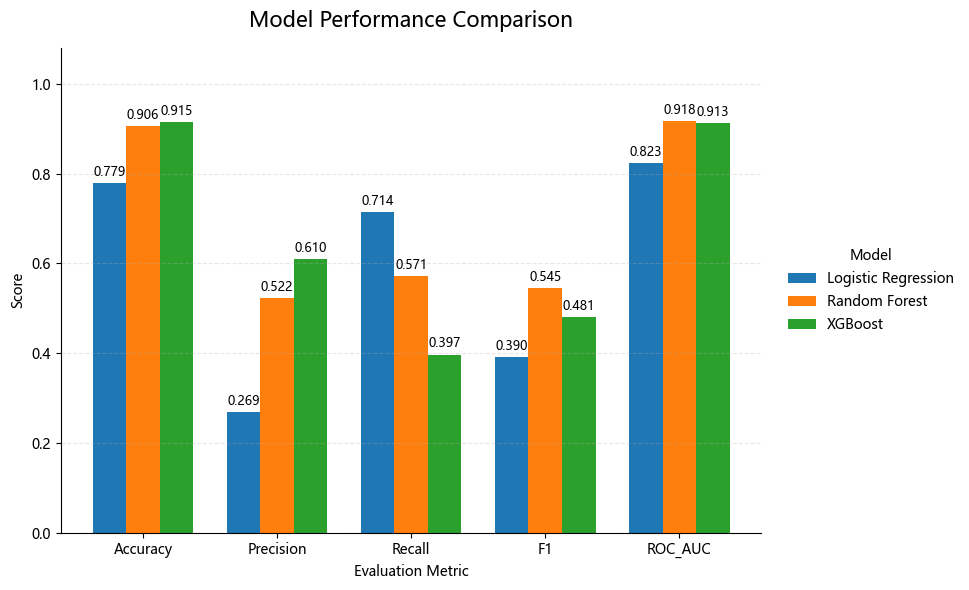

In [126]:
# ==========================================
# 模型指标可视化
# ==========================================

import numpy as np
import matplotlib.pyplot as plt

metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, (_, row) in enumerate(comparison_df.iterrows()):
    values = row[metrics].astype(float).values

    bars = ax.bar(
        x + (i - (len(comparison_df) - 1) / 2) * width,
        values,
        width,
        label=row["Model"]
    )

    ax.bar_label(
        bars,
        labels=[f"{v:.3f}" for v in values],
        padding=3,
        fontsize=9
    )

ax.set_title("Model Performance Comparison", fontsize=15, pad=15)
ax.set_xlabel("Evaluation Metric")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.08)

ax.grid(axis="y", linestyle="--", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# 将图例移动到图表右侧
ax.legend(
    title="Model",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# 为右侧图例预留空间
plt.tight_layout(rect=[0, 0, 0.82, 1])

plt.show()

#### 对比结果分析

从整体结果来看，**Random Forest 是本项目综合表现最优的模型**。

虽然XGBoost取得了最高的Accuracy（0.9150）和Precision（0.6098），但其Recall仅为0.3968，意味着超过一半的真实爆款视频未被成功识别。对于本文的爆款识别任务而言，**漏判潜在爆款的业务成本通常高于误判成本**，因此仅依赖Precision并不足以作为模型选择依据。

相比之下，Logistic Regression取得了最高的Recall（0.7143），能够识别更多真实爆款视频，但Precision仅为0.2687，说明模型产生了较多误判，预测结果稳定性不足。

**Random Forest在Precision（0.5217）和Recall（0.5714）之间取得了较好的平衡。**

同时：

- **F1 Score最高（0.5455）**
- **ROC-AUC最高（0.9177）**

说明该模型不仅能够识别较多潜在爆款视频，同时具备较强的整体区分能力。

---

#### 最终模型选择

综合Accuracy、Precision、Recall、F1 Score和ROC-AUC等指标表现，**Random Forest为本项目最终选择的预测模型。**

选择原因主要包括：

- **爆款视频识别能力较强（Recall较高）**
- **误判控制能力较好（Precision较高）**
- **综合表现最佳（F1 Score最高）**
- **整体区分能力最强（ROC-AUC最高）**

因此，Random Forest更符合本项目的业务目标，即在控制误判风险的同时，尽可能发现更多潜在爆款视频。

### 7.8 特征重要性分析

在确定Random Forest为本项目最终模型后，本节进一步分析影响爆款视频预测的关键因素。
通过分析模型识别爆款视频时重点关注的特征，可以进一步理解爆款视频形成过程中可能存在的关键影响因素，并为内容创作与运营策略制定提供参考依据。

In [127]:
# ==========================================
# 7.8 特征重要性分析
# ==========================================

import pandas as pd
import numpy as np

# ==========================================
# 获取最优模型
# ==========================================

rf_model = best_rf.named_steps["model"]

# ==========================================
# 获取预处理后的特征名称
# ==========================================

feature_names = (
    best_rf
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# ==========================================
# 获取特征重要性
# ==========================================

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

# ==========================================
# 按重要度排序
# ==========================================

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

# 查看前20个重要特征（编码后）
feature_importance.head(20)



,Feature,Importance
50,num__channel_avg_views,0.502027
49,num__channel_video_count,0.088218
47,num__title_length,0.075385
48,num__tag_count,0.058717
7,cat__category_name_Music,0.030542
8,cat__category_name_News & Politics,0.013624
3,cat__category_name_Entertainment,0.010782
14,cat__category_name_Sports,0.010303
38,cat__publish_hour_22,0.009695
44,cat__publish_weekday_Thursday,0.009424


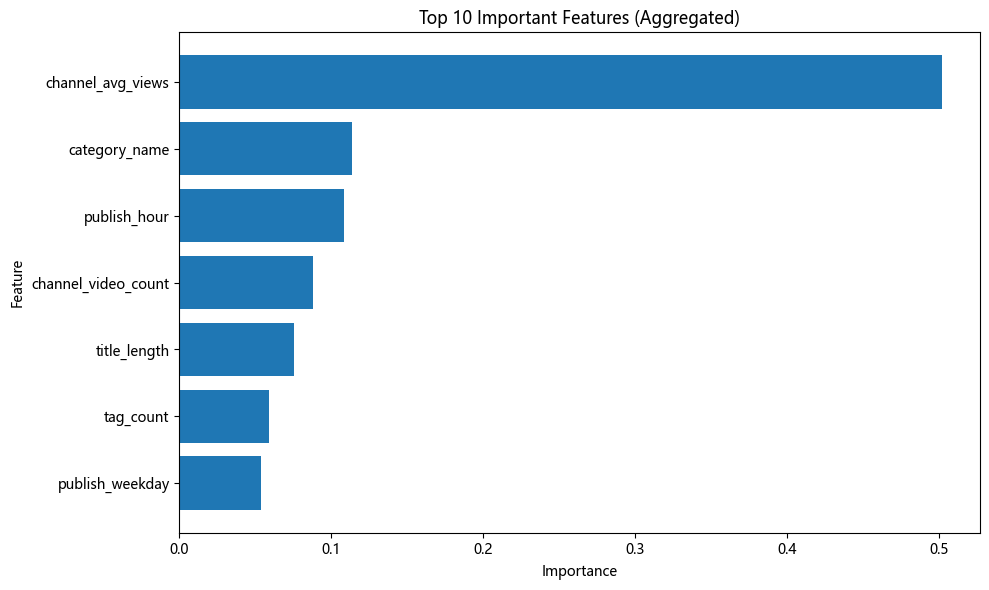

In [128]:
# ==========================================
# 特征重要性聚合——同一原始特征汇总
# ==========================================

# One-Hot 编码将 category_name / publish_hour / publish_weekday
# 拆成了多个哑变量，需要将同源哑变量的重要度求和，
# 恢复到原始特征维度，便于与第6章机制分析结论对照。

agg_importance = []

# 类别型特征：匹配 cat__{feature}_{value} 并加总
for feat in categorical_features:
    mask = feature_importance["Feature"].str.startswith(f"cat__{feat}_")
    total = feature_importance.loc[mask, "Importance"].sum()
    agg_importance.append({"Feature": feat, "Importance": total})

# 数值型特征：直接匹配 num__{feature}
for feat in numeric_features:
    name = f"num__{feat}"
    total = feature_importance.loc[
        feature_importance["Feature"] == name, "Importance"
    ].sum()
    agg_importance.append({"Feature": feat, "Importance": total})

agg_df = (
    pd.DataFrame(agg_importance)
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

agg_df

# ==========================================
# Top10 特征重要性可视化
# ==========================================

import matplotlib.pyplot as plt

top10 = agg_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["Feature"][::-1],
    top10["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features (Aggregated)")
plt.tight_layout()
plt.show()



#### 影响爆款视频的关键特征分析

Random Forest特征重要性分析结果表明，
- **创作者历史影响力**

是影响视频成为爆款的最关键因素。其中，频道历史平均播放量（channel_avg_views）的重要性达到0.502，显著高于其他特征，说明创作者长期积累的影响力是影响视频传播效果的最重要关联因素之一。

除创作者影响力外，
- **内容类别（category_name）**

的重要性排名第二，表明不同内容赛道存在明显的传播能力差异。

发布时间相关特征同样具有一定预测价值，而标题长度和标签数量等内容包装因素的重要性相对较低。

**综合来看，影响爆款视频形成的因素重要性呈现：**

> **创作者影响力 ＞ 内容赛道 ＞ 发布时间 ＞ 内容包装**

这一结果说明，爆款视频的形成不仅取决于单条视频内容，更受到创作者长期影响力和内容赛道选择的共同影响。

## 8. 项目总结与业务启示

### 8.1 核心结论

本项目基于YouTube Trending公开数据，从内容属性、发布时间、创作者影响力等多个维度，对热门视频的形成规律进行了探索分析，并构建机器学习模型识别 Trending 视频是否达到爆款标准。

结合探索性分析、爆款机制分析以及机器学习建模结果，可以得到以下核心结论：

#### （1）创作者影响力是与爆款表现关联最强的因素

特征重要性分析结果显示，创作者相关特征对模型预测贡献最大。

相比单条视频的标题优化、标签设置等内容包装因素，频道长期积累的用户基础和内容影响力对视频传播效果具有更重要的作用。

综合分析结果表明：

> **创作者影响力 ＞ 内容赛道 ＞ 发布时间 ＞ 内容包装**

在本项目分析维度中，创作者影响力与爆款表现的关联最为突出。

#### （2）内容赛道存在明显传播差异

不同内容类别在播放量表现和爆款率方面存在显著差异。

其中，Music、Entertainment等类别整体表现较好，说明内容赛道本身会影响视频传播效果。

对于创作者而言，内容方向选择不仅影响创作定位，也会影响视频获得传播机会的概率。

#### （3）发布时间会影响视频传播表现

发布时间相关特征具备一定预测能力。

虽然其影响程度低于创作者影响力和内容赛道，但合理的发布时间安排仍有助于提升内容曝光机会，从而在 Trending 样本中更可能达到爆款标准。

#### （4）公开数据条件下仍具备一定预测能力

本项目构建了Logistic Regression、Random Forest和XGBoost三类模型，并从Accuracy、Precision、Recall、F1 Score以及ROC-AUC等维度进行综合评估。

最终Random Forest表现最佳，说明即使在缺少平台内部数据的情况下，仅利用公开视频数据仍能够识别部分爆款规律，并实现对潜在热门内容的有效预测。

---

### 8.2 业务启示

#### 对内容创作者

相比追求单条视频的偶然爆发，持续提升频道整体表现更具长期价值。

稳定的内容输出、持续积累用户群体以及形成明确的内容定位，是提高爆款产出能力的重要基础。

#### 对内容运营团队

内容赛道和发布时间均会影响传播表现。

运营团队可以结合历史数据识别高潜力内容方向，并通过优化发布时间提升内容曝光效率，提高内容运营效果。

#### 对内容平台

创作者历史表现、内容类别以及发布时间等因素均具有较高预测价值。

在内容推荐和流量分发过程中，可将相关特征作为辅助参考指标，提高热门内容识别效率。

---

### 8.3 局限性与未来优化方向

需要说明的是，本项目使用的数据主要来源于YouTube公开热门榜单数据。相比平台内部推荐系统所掌握的曝光量、点击率、观看时长、完播率以及用户行为等核心指标，公开数据能够反映的更多是内容传播结果而非完整传播过程。

因此，本项目更适合理解热门内容之间的差异规律，以及探索在有限数据条件下如何识别潜在爆款视频，而非完全还原平台推荐机制。

未来可进一步扩展不同国家和时间范围的数据，引入标题文本、视频描述、缩略图等非结构化信息，构建更加丰富的内容特征体系。同时结合用户行为数据、创作者成长轨迹以及时序预测方法，进一步提升模型解释能力与预测效果。



需要特别强调的是，由于本项目使用的数据样本均来自 YouTube Trending 榜单，所有分析结论主要反映 Trending 视频内部爆款与普通视频之间的表现差异，不宜直接推广至 YouTube 全量视频，也不能用于判断任意视频是否能够进入 Trending 榜单。模型预测目标为本文定义的爆款标准（播放量前25%且互动率前40%），而非视频是否上榜。
总体而言，本项目验证了数据分析与机器学习方法在内容传播研究中的应用价值，并证明在公开数据条件下，仍能够从创作者影响力、内容赛道和发布时间等维度发现具有业务价值的传播规律，为热门内容分析与爆款预测提供数据支持。